# Full Pair Comparison

Runs 81 total variants across the three requested pair-comparison cases. Each case sweeps scenarios 1-3, robust epsilon starts `0.25`, `0.5`, `1.0`, and epsilon schedules `linear`, `exponential`, `constant`.

In [1]:
from pathlib import Path
import dataclasses
import sys

notebook_dir = Path.cwd()
if notebook_dir.name != "bimatrix_game":
    candidate = notebook_dir / "discrete_action_space" / "bimatrix_game"
    if candidate.exists():
        notebook_dir = candidate.resolve()

for path in (notebook_dir, notebook_dir.parent):
    if str(path) not in sys.path:
        sys.path.insert(0, str(path))

from experiment_harness import (
    BASE_SEED,
    DEEP_SRQ_HYPERPARAMS,
    SCENARIO_CONFIGS,
    configure_path_runtime,
    save_training_stats,
    train_pairing,
)
from stats_utils import load_training_stats

discrete_action_space_dir = notebook_dir.parent
pathwrap_path = Path(configure_path_runtime(discrete_action_space_dir)).resolve()
if not pathwrap_path.exists():
    raise FileNotFoundError(f"PATH solver library not found at {pathwrap_path}")


In [2]:
def run_pair_epsilon_sweep(
    *,
    pairing,
    case_slug,
    case_seed_offset,
    scenarios,
    scenario_configs,
    epsilon_starts,
    epsilon_schedules,
    n_episodes,
    base_seed,
    output_root,
    use_gpu,
    write_plots,
    base_hyperparameters,
    hyperparameter_overrides,
):
    results = {}
    case_output_root = Path(output_root) / case_slug

    def variant_stats_path(scenario_key, epsilon_start, epsilon_schedule, variant_key, seed):
        run_slug_parts = []
        for algorithm in pairing:
            if algorithm == "nashq":
                run_slug_parts.append("nashq")
            else:
                run_slug_parts.append(
                    f"{algorithm}_{epsilon_schedule}_eps{float(epsilon_start):g}"
                )
        run_slug = "_vs_".join(run_slug_parts)
        run_slug = f"{run_slug}_{variant_key}_{seed}"
        return case_output_root / scenario_key / run_slug / "training_stats.txt"

    for scenario_index, scenario_key in enumerate(scenarios):
        scenario_config = scenario_configs[scenario_key]
        scenario_results = {}

        for schedule_index, epsilon_schedule in enumerate(epsilon_schedules):
            for epsilon_index, epsilon_start in enumerate(epsilon_starts):
                seed = (
                    base_seed
                    + case_seed_offset
                    + scenario_index * 1000
                    + schedule_index * 100
                    + epsilon_index
                )
                variant_key = f"eps{epsilon_start:g}_{epsilon_schedule}"
                hyperparameters = dataclasses.replace(
                    base_hyperparameters,
                    **hyperparameter_overrides,
                    epsilon_robust=float(epsilon_start),
                    epsilon_robust_initial=float(epsilon_start),
                    epsilon_schedule=epsilon_schedule,
                )
                epsilon_robust_initials = tuple(
                    None if algorithm == "nashq" else float(epsilon_start)
                    for algorithm in pairing
                )
                per_agent_schedules = tuple(
                    None if algorithm == "nashq" else epsilon_schedule
                    for algorithm in pairing
                )

                stats_path = variant_stats_path(
                    scenario_key,
                    epsilon_start,
                    epsilon_schedule,
                    variant_key,
                    seed,
                )
                if stats_path.exists():
                    stats = load_training_stats(stats_path)
                    print(f"Skipping existing run: {stats_path}")
                else:
                    stats = train_pairing(
                        scenario_key=scenario_key,
                        scenario_config=scenario_config,
                        pairing=pairing,
                        n_episodes=n_episodes,
                        seed=seed,
                        output_root=case_output_root,
                        use_gpu=use_gpu,
                        write_plots=write_plots,
                        hyperparameters=hyperparameters,
                        epsilon_robust_initials=epsilon_robust_initials,
                        epsilon_schedules=per_agent_schedules,
                        run_name_suffix=variant_key,
                        include_episode_durations=False,
                        print_full_stats=False,
                    )
                stats["case_slug"] = case_slug
                stats["variant_key"] = variant_key
                stats["case_seed_offset"] = int(case_seed_offset)
                scenario_results[variant_key] = stats

        results[scenario_key] = scenario_results

    return results


In [3]:
scenarios = ("scenario1", "scenario2", "scenario3")
epsilon_starts = (0.25, 0.5, 1.0)
epsilon_schedules = ("linear", "exponential", "constant")

solver_name = "path_c_pool"
network_type = "joint_output"
n_episodes = 3000
batch_size = 16
target_update = 100
use_gpu = True
write_plots = True

scenario_configs = SCENARIO_CONFIGS
base_hyperparameters = DEEP_SRQ_HYPERPARAMS

# Applied only to Deep SRQ agents. Tabular SRQ/NashQ use their own configs.
deep_srq_hyperparameter_overrides = {
    "batch_size": batch_size,
    "target_update_steps": target_update,
    "sre_solver_name": solver_name,
    "sre_num_repeats": 5,
    "sre_include_pure_starts": True,
    "network_type": network_type,
    "sre_solver_workers": 8,
    "sre_solver_start_method": None,
}

full_pair_output_root = Path("full_pair_comparison_runs")

common_sweep_kwargs = {
    "scenarios": scenarios,
    "scenario_configs": scenario_configs,
    "epsilon_starts": epsilon_starts,
    "epsilon_schedules": epsilon_schedules,
    "n_episodes": n_episodes,
    "base_seed": BASE_SEED,
    "output_root": full_pair_output_root,
    "use_gpu": use_gpu,
    "write_plots": write_plots,
    "base_hyperparameters": base_hyperparameters,
    "hyperparameter_overrides": deep_srq_hyperparameter_overrides,
}


## Deep SRQ vs Deep SRQ

In [4]:
deep_srq_vs_deep_srq_results = run_pair_epsilon_sweep(
    pairing=("deep_srq", "deep_srq"),
    case_slug="deep_srq_vs_deep_srq",
    case_seed_offset=0,
    **common_sweep_kwargs,
)

save_training_stats(
    full_pair_output_root / "deep_srq_vs_deep_srq_manifest.txt",
    deep_srq_vs_deep_srq_results,
)


Skipping existing run: full_pair_comparison_runs/deep_srq_vs_deep_srq/scenario1/deep_srq_linear_eps0.25_vs_deep_srq_linear_eps0.25_eps0.25_linear_2025/training_stats.txt
Skipping existing run: full_pair_comparison_runs/deep_srq_vs_deep_srq/scenario1/deep_srq_linear_eps0.5_vs_deep_srq_linear_eps0.5_eps0.5_linear_2026/training_stats.txt
Skipping existing run: full_pair_comparison_runs/deep_srq_vs_deep_srq/scenario1/deep_srq_linear_eps1_vs_deep_srq_linear_eps1_eps1_linear_2027/training_stats.txt
Skipping existing run: full_pair_comparison_runs/deep_srq_vs_deep_srq/scenario1/deep_srq_exponential_eps0.25_vs_deep_srq_exponential_eps0.25_eps0.25_exponential_2125/training_stats.txt
Skipping existing run: full_pair_comparison_runs/deep_srq_vs_deep_srq/scenario1/deep_srq_exponential_eps0.5_vs_deep_srq_exponential_eps0.5_eps0.5_exponential_2126/training_stats.txt
Skipping existing run: full_pair_comparison_runs/deep_srq_vs_deep_srq/scenario1/deep_srq_exponential_eps1_vs_deep_srq_exponential_eps1_

PosixPath('full_pair_comparison_runs/deep_srq_vs_deep_srq_manifest.txt')

## Deep SRQ vs Tabular SRQ

Skipping existing run: full_pair_comparison_runs/deep_srq_vs_tabular_srq/scenario1/deep_srq_linear_eps0.25_vs_srq_linear_eps0.25_eps0.25_linear_12025/training_stats.txt
Skipping existing run: full_pair_comparison_runs/deep_srq_vs_tabular_srq/scenario1/deep_srq_linear_eps0.5_vs_srq_linear_eps0.5_eps0.5_linear_12026/training_stats.txt
Skipping existing run: full_pair_comparison_runs/deep_srq_vs_tabular_srq/scenario1/deep_srq_linear_eps1_vs_srq_linear_eps1_eps1_linear_12027/training_stats.txt
Skipping existing run: full_pair_comparison_runs/deep_srq_vs_tabular_srq/scenario1/deep_srq_exponential_eps0.25_vs_srq_exponential_eps0.25_eps0.25_exponential_12125/training_stats.txt
Skipping existing run: full_pair_comparison_runs/deep_srq_vs_tabular_srq/scenario1/deep_srq_exponential_eps0.5_vs_srq_exponential_eps0.5_eps0.5_exponential_12126/training_stats.txt
Skipping existing run: full_pair_comparison_runs/deep_srq_vs_tabular_srq/scenario1/deep_srq_exponential_eps1_vs_srq_exponential_eps1_eps1_ex

scenario3: deep_srq_vs_srq: 100%|██████████| 3000/3000 [1:27:30<00:00,  1.75s/it]


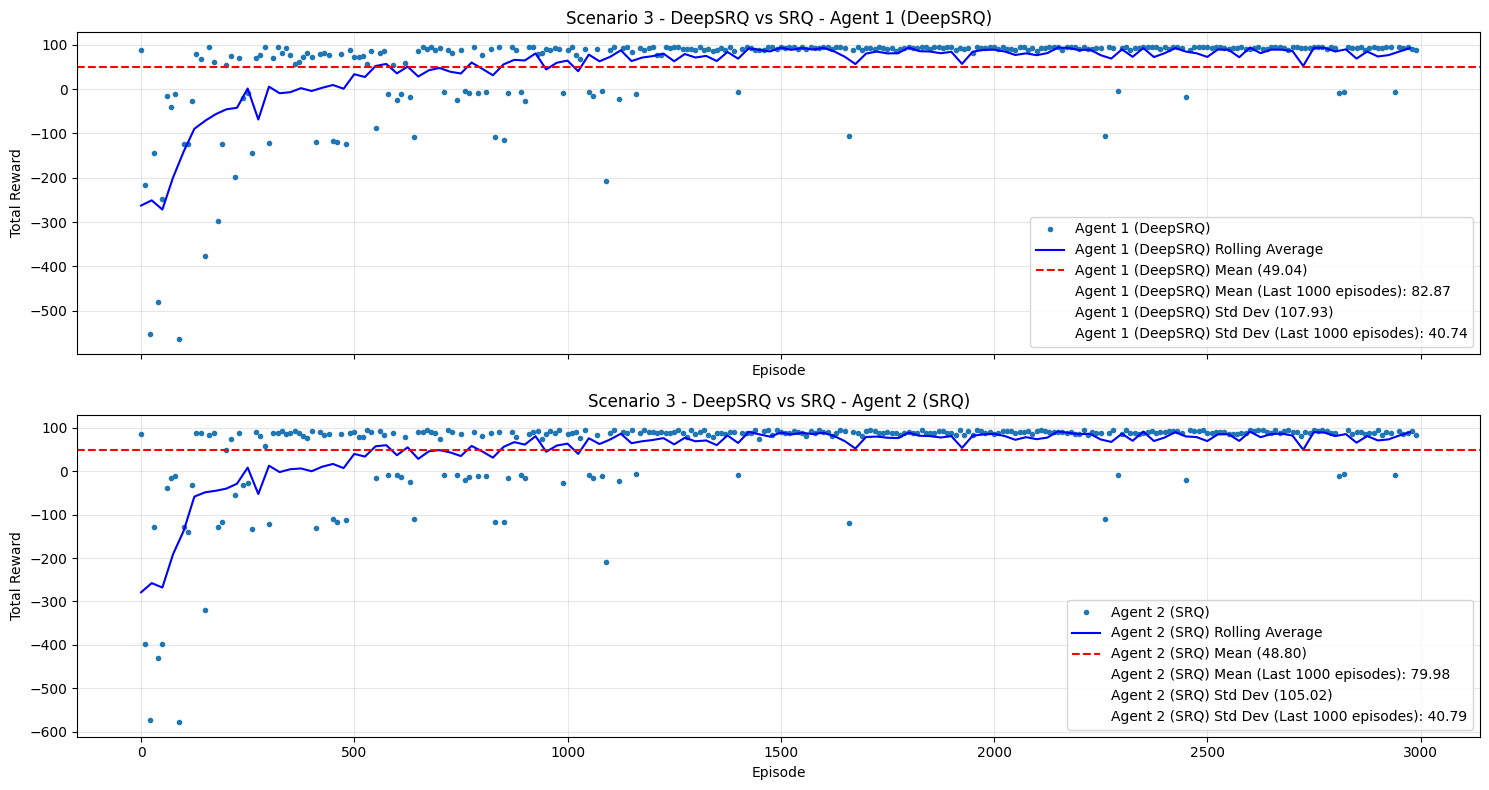

Saved stats to full_pair_comparison_runs/deep_srq_vs_tabular_srq/scenario3/deep_srq_constant_eps0.25_vs_srq_constant_eps0.25_eps0.25_constant_14225/training_stats.txt
Scenario 3 - DeepSRQ vs SRQ - deep_srq_constant_eps0.25_vs_srq_constant_eps0.25_eps0.25_constant_14225
Wall clock: 5540.231s (92.34 min)
Episode time:   count=3000, mean=1.845904s (1845903.77 us), min=0.276046s, max=11.761519s, std=1.539643s
SRE solve time: count=946484, mean=0.005195s (5194.76 us), min=0.001315s, max=0.240502s, std=0.007312s
Backend solve:  count=4934944, mean=0.002921s (2920.69 us), min=0.000109s, max=0.649066s, std=0.005912s
  Agent 0 (deep_srq)
    SRE solve:  count=832528, mean=0.003059s (3059.15 us), min=0.001315s, max=0.110584s, std=0.002321s
    Backend:    count=832528, mean=0.014847s (14847.25 us), min=0.006400s, max=0.649066s, std=0.005820s
    Update:     count=55979, mean=0.046223s (46222.73 us), min=0.022931s, max=1.080206s, std=0.011520s
  Agent 1 (srq)
    SRE solve:  count=113956, mean=0.

scenario3: deep_srq_vs_srq: 100%|██████████| 3000/3000 [1:26:29<00:00,  1.73s/it]


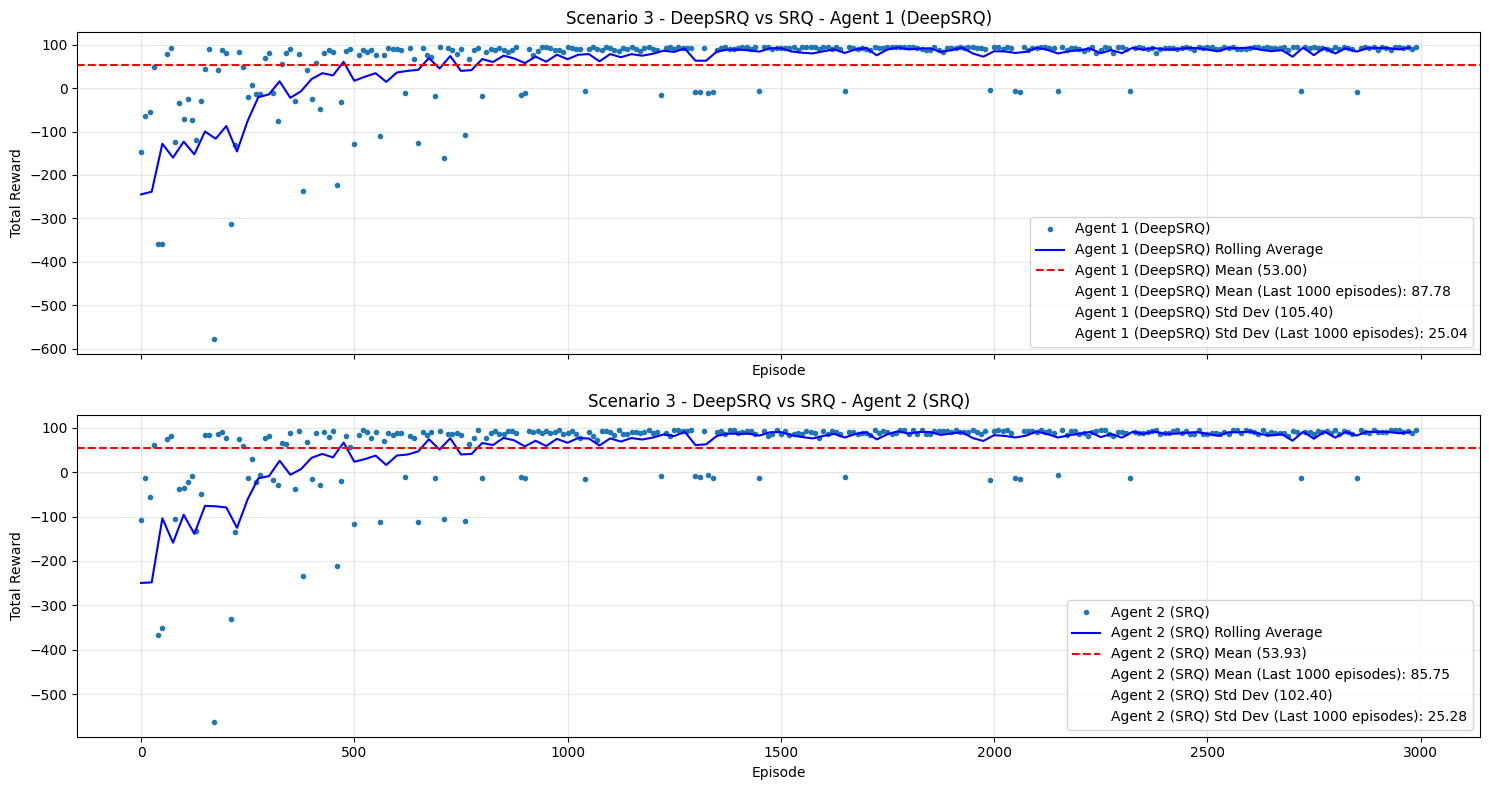

Saved stats to full_pair_comparison_runs/deep_srq_vs_tabular_srq/scenario3/deep_srq_constant_eps0.5_vs_srq_constant_eps0.5_eps0.5_constant_14226/training_stats.txt
Scenario 3 - DeepSRQ vs SRQ - deep_srq_constant_eps0.5_vs_srq_constant_eps0.5_eps0.5_constant_14226
Wall clock: 5478.304s (91.31 min)
Episode time:   count=3000, mean=1.825224s (1825223.69 us), min=0.438511s, max=13.260219s, std=1.509993s
SRE solve time: count=942928, mean=0.005146s (5145.95 us), min=0.001440s, max=0.401151s, std=0.007397s
Backend solve:  count=4903808, mean=0.002923s (2922.71 us), min=0.000107s, max=0.383517s, std=0.005801s
  Agent 0 (deep_srq)
    SRE solve:  count=829760, mean=0.002972s (2971.96 us), min=0.001440s, max=0.088494s, std=0.002296s
    Backend:    count=829760, mean=0.014779s (14778.75 us), min=0.007152s, max=0.383517s, std=0.005218s
    Update:     count=55585, mean=0.045279s (45278.92 us), min=0.026083s, max=0.416216s, std=0.009590s
  Agent 1 (srq)
    SRE solve:  count=113168, mean=0.021086

scenario3: deep_srq_vs_srq: 100%|██████████| 3000/3000 [1:25:36<00:00,  1.71s/it]


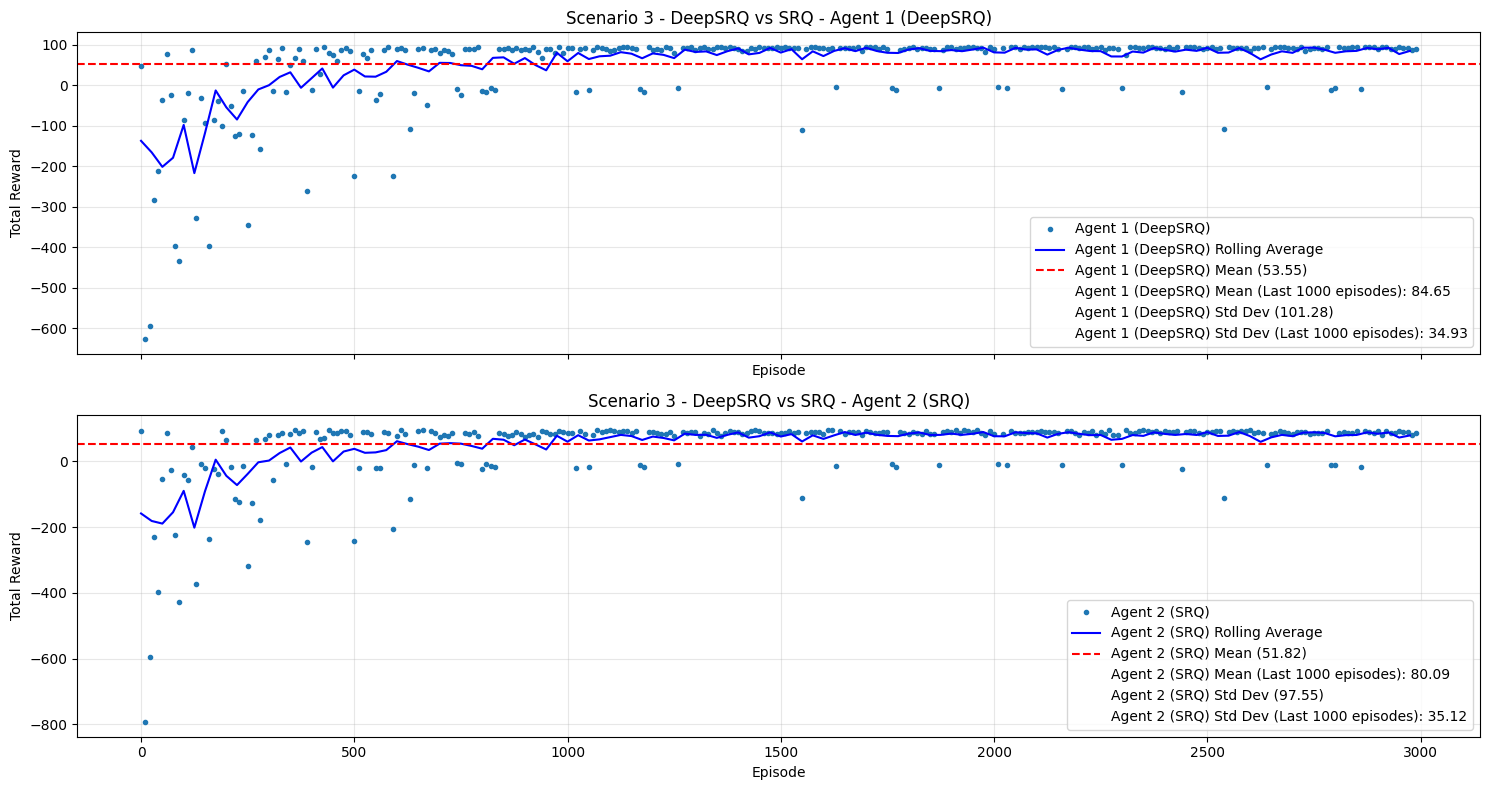

Saved stats to full_pair_comparison_runs/deep_srq_vs_tabular_srq/scenario3/deep_srq_constant_eps1_vs_srq_constant_eps1_eps1_constant_14227/training_stats.txt
Scenario 3 - DeepSRQ vs SRQ - deep_srq_constant_eps1_vs_srq_constant_eps1_eps1_constant_14227
Wall clock: 5402.441s (90.04 min)
Episode time:   count=3000, mean=1.800009s (1800009.16 us), min=0.493366s, max=9.620778s, std=1.347416s
SRE solve time: count=1005547, mean=0.004739s (4739.48 us), min=0.001368s, max=0.377450s, std=0.007076s
Backend solve:  count=5251187, mean=0.002601s (2601.20 us), min=0.000095s, max=0.818669s, std=0.005155s
  Agent 0 (deep_srq)
    SRE solve:  count=884243, mean=0.002664s (2663.59 us), min=0.001368s, max=0.066942s, std=0.002123s
    Backend:    count=884243, mean=0.013089s (13088.93 us), min=0.007039s, max=0.818669s, std=0.004804s
    Update:     count=59653, mean=0.040587s (40586.82 us), min=0.021298s, max=0.828703s, std=0.011055s
  Agent 1 (srq)
    SRE solve:  count=121304, mean=0.019872s (19871.62 

PosixPath('full_pair_comparison_runs/deep_srq_vs_tabular_srq_manifest.txt')

In [5]:
deep_srq_vs_tabular_srq_results = run_pair_epsilon_sweep(
    pairing=("deep_srq", "srq"),
    case_slug="deep_srq_vs_tabular_srq",
    case_seed_offset=10_000,
    **common_sweep_kwargs,
)

save_training_stats(
    full_pair_output_root / "deep_srq_vs_tabular_srq_manifest.txt",
    deep_srq_vs_tabular_srq_results,
)


## Deep SRQ vs Nash Q

Training DeepSRQ vs NashQ on Scenario 1 for 3000 episodes | seed=22025.


scenario1: deep_srq_vs_nashq: 100%|██████████| 3000/3000 [56:42<00:00,  1.13s/it]  


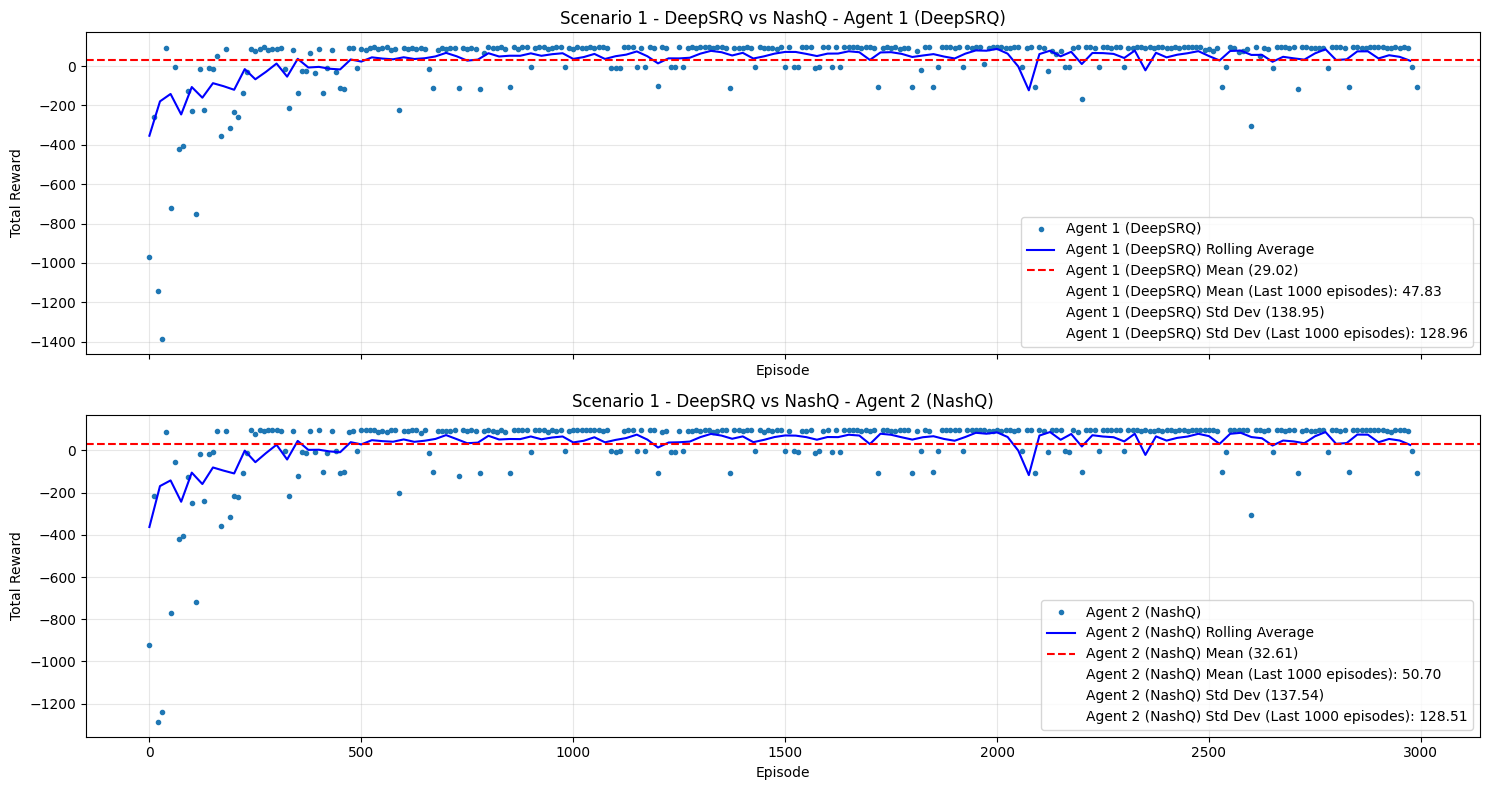

Saved stats to full_pair_comparison_runs/deep_srq_vs_nash_q/scenario1/deep_srq_linear_eps0.25_vs_nashq_eps0.25_linear_22025/training_stats.txt
Scenario 1 - DeepSRQ vs NashQ - deep_srq_linear_eps0.25_vs_nashq_eps0.25_linear_22025
Wall clock: 3547.515s (59.13 min)
Episode time:   count=3000, mean=1.181708s (1181708.33 us), min=0.358678s, max=10.662027s, std=0.961622s
SRE solve time: count=506940, mean=0.003698s (3697.83 us), min=0.001588s, max=0.130663s, std=0.002972s
Backend solve:  count=506940, mean=0.016062s (16062.11 us), min=0.007514s, max=0.321836s, std=0.007090s
  Agent 0 (deep_srq)
    SRE solve:  count=506940, mean=0.003698s (3697.83 us), min=0.001588s, max=0.130663s, std=0.002972s
    Backend:    count=506940, mean=0.016062s (16062.11 us), min=0.007514s, max=0.321836s, std=0.007090s
    Update:     count=38999, mean=0.047081s (47080.78 us), min=0.021475s, max=1.055027s, std=0.013164s
  Agent 1 (nashq)
    SRE solve:  count=0
    Backend:    count=0
    Update:     count=39998,

scenario1: deep_srq_vs_nashq: 100%|██████████| 3000/3000 [45:30<00:00,  1.10it/s] 


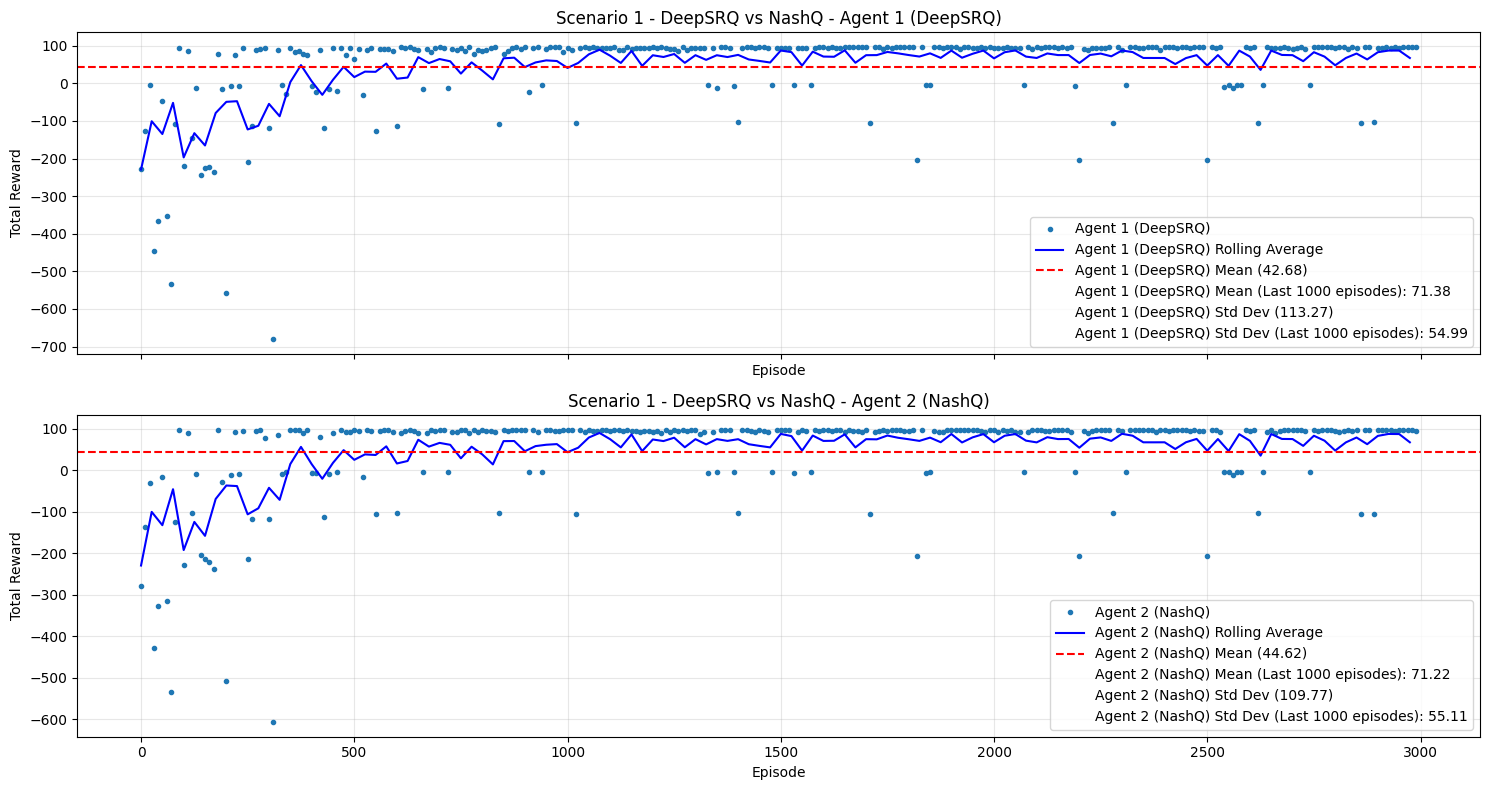

Saved stats to full_pair_comparison_runs/deep_srq_vs_nash_q/scenario1/deep_srq_linear_eps0.5_vs_nashq_eps0.5_linear_22026/training_stats.txt
Scenario 1 - DeepSRQ vs NashQ - deep_srq_linear_eps0.5_vs_nashq_eps0.5_linear_22026
Wall clock: 2839.631s (47.33 min)
Episode time:   count=3000, mean=0.945818s (945818.31 us), min=0.329859s, max=9.364696s, std=0.824772s
SRE solve time: count=428866, mean=0.003406s (3405.64 us), min=0.001425s, max=0.079506s, std=0.002694s
Backend solve:  count=428866, mean=0.015218s (15217.92 us), min=0.007515s, max=1.021702s, std=0.006464s
  Agent 0 (deep_srq)
    SRE solve:  count=428866, mean=0.003406s (3405.64 us), min=0.001425s, max=0.079506s, std=0.002694s
    Backend:    count=428866, mean=0.015218s (15217.92 us), min=0.007515s, max=1.021702s, std=0.006464s
    Update:     count=32981, mean=0.044460s (44459.91 us), min=0.020016s, max=1.042637s, std=0.013090s
  Agent 1 (nashq)
    SRE solve:  count=0
    Backend:    count=0
    Update:     count=33980, mean=

scenario1: deep_srq_vs_nashq: 100%|██████████| 3000/3000 [47:01<00:00,  1.06it/s] 


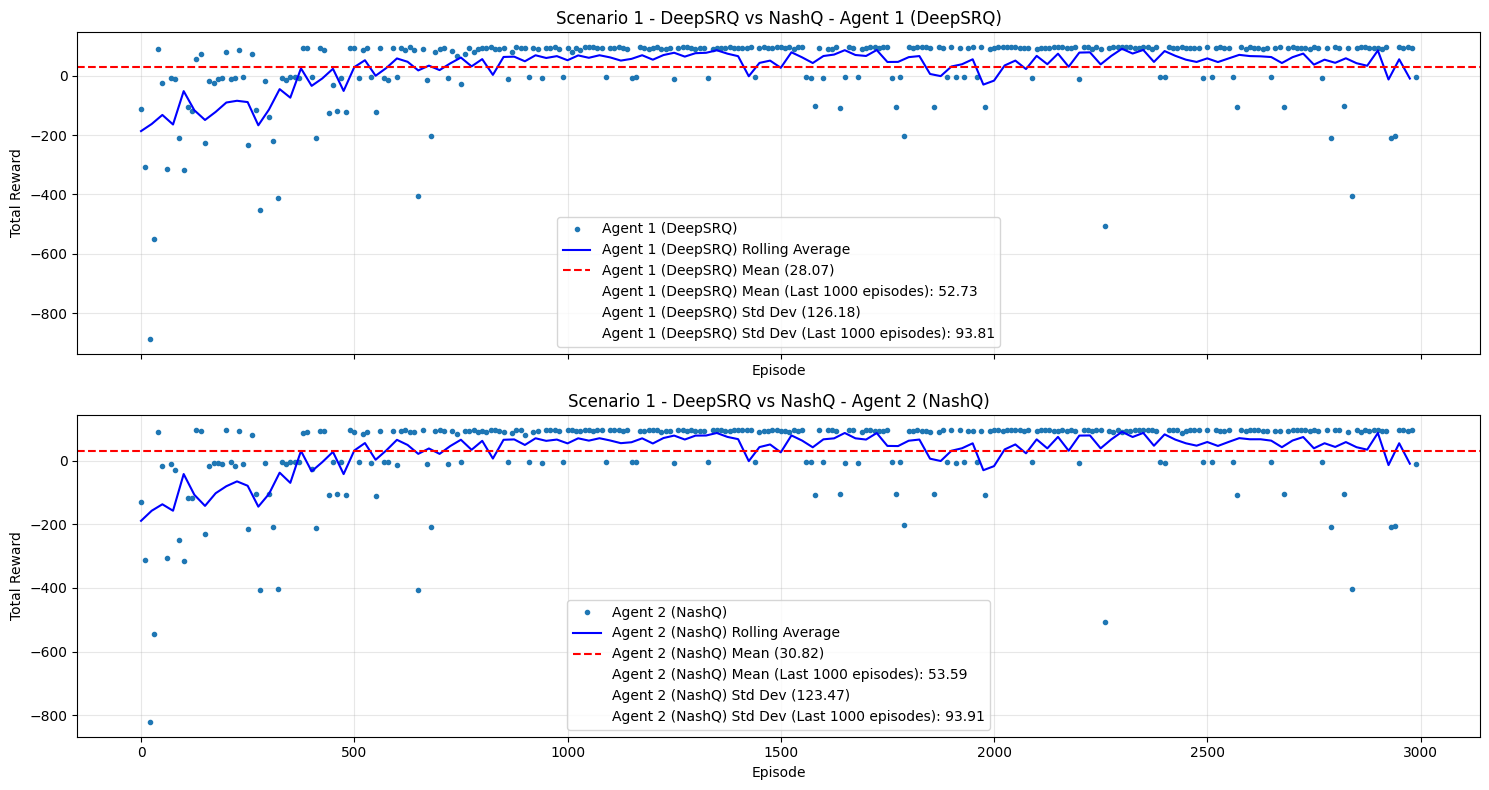

Saved stats to full_pair_comparison_runs/deep_srq_vs_nash_q/scenario1/deep_srq_linear_eps1_vs_nashq_eps1_linear_22027/training_stats.txt
Scenario 1 - DeepSRQ vs NashQ - deep_srq_linear_eps1_vs_nashq_eps1_linear_22027
Wall clock: 2930.306s (48.84 min)
Episode time:   count=3000, mean=0.976017s (976017.17 us), min=0.110154s, max=9.291339s, std=0.728674s
SRE solve time: count=445590, mean=0.003469s (3468.53 us), min=0.001283s, max=0.296025s, std=0.003242s
Backend solve:  count=445590, mean=0.015396s (15396.48 us), min=0.007354s, max=0.310220s, std=0.006945s
  Agent 0 (deep_srq)
    SRE solve:  count=445590, mean=0.003469s (3468.53 us), min=0.001283s, max=0.296025s, std=0.003242s
    Backend:    count=445590, mean=0.015396s (15396.48 us), min=0.007354s, max=0.310220s, std=0.006945s
    Update:     count=34184, mean=0.044179s (44178.53 us), min=0.020580s, max=0.331414s, std=0.012000s
  Agent 1 (nashq)
    SRE solve:  count=0
    Backend:    count=0
    Update:     count=35183, mean=0.000011

scenario1: deep_srq_vs_nashq: 100%|██████████| 3000/3000 [49:46<00:00,  1.00it/s] 


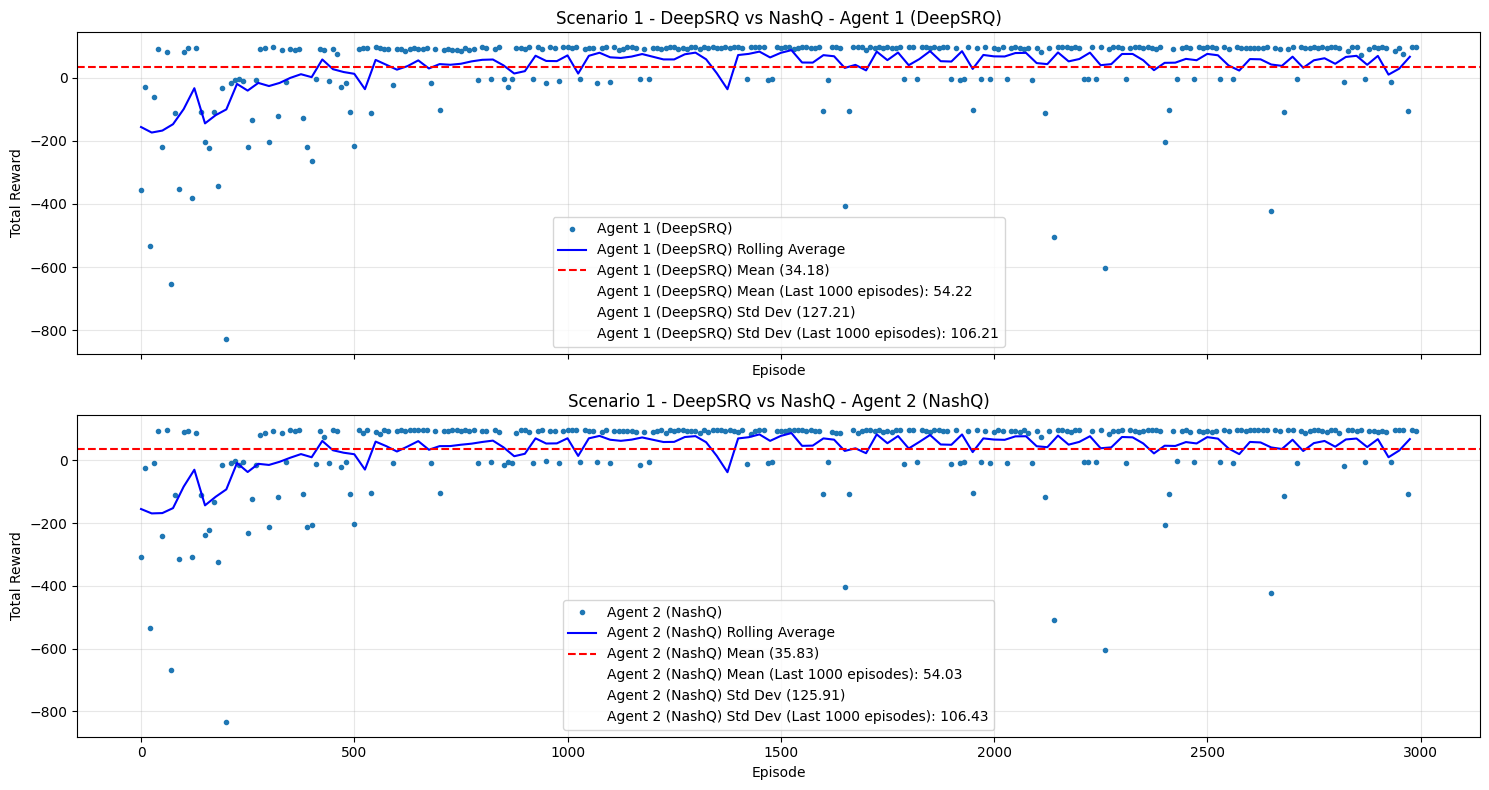

Saved stats to full_pair_comparison_runs/deep_srq_vs_nash_q/scenario1/deep_srq_exponential_eps0.25_vs_nashq_eps0.25_exponential_22125/training_stats.txt
Scenario 1 - DeepSRQ vs NashQ - deep_srq_exponential_eps0.25_vs_nashq_eps0.25_exponential_22125
Wall clock: 3093.222s (51.55 min)
Episode time:   count=3000, mean=1.030327s (1030326.63 us), min=0.252859s, max=9.842524s, std=0.857759s
SRE solve time: count=470741, mean=0.003458s (3457.95 us), min=0.001539s, max=0.086771s, std=0.002692s
Backend solve:  count=470741, mean=0.015478s (15478.04 us), min=0.007162s, max=0.346840s, std=0.006591s
  Agent 0 (deep_srq)
    SRE solve:  count=470741, mean=0.003458s (3457.95 us), min=0.001539s, max=0.086771s, std=0.002692s
    Backend:    count=470741, mean=0.015478s (15478.04 us), min=0.007162s, max=0.346840s, std=0.006591s
    Update:     count=35664, mean=0.045377s (45376.57 us), min=0.021441s, max=0.374916s, std=0.011722s
  Agent 1 (nashq)
    SRE solve:  count=0
    Backend:    count=0
    Updat

scenario1: deep_srq_vs_nashq: 100%|██████████| 3000/3000 [44:42<00:00,  1.12it/s] 


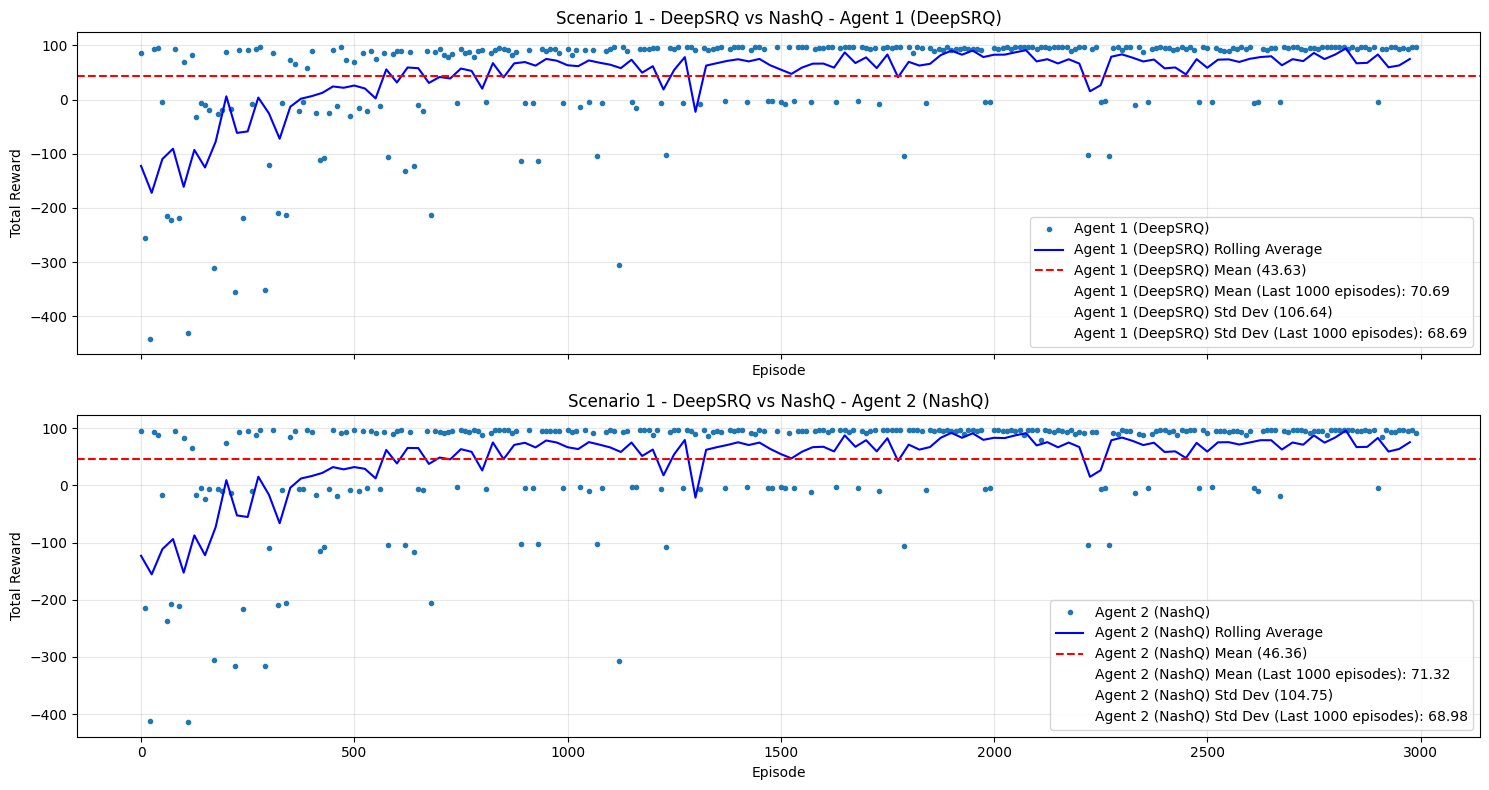

Saved stats to full_pair_comparison_runs/deep_srq_vs_nash_q/scenario1/deep_srq_exponential_eps0.5_vs_nashq_eps0.5_exponential_22126/training_stats.txt
Scenario 1 - DeepSRQ vs NashQ - deep_srq_exponential_eps0.5_vs_nashq_eps0.5_exponential_22126
Wall clock: 2772.680s (46.21 min)
Episode time:   count=3000, mean=0.923489s (923489.14 us), min=0.136121s, max=10.608625s, std=0.761894s
SRE solve time: count=436025, mean=0.003258s (3258.30 us), min=0.001370s, max=0.175741s, std=0.002539s
Backend solve:  count=436025, mean=0.014784s (14783.82 us), min=0.007451s, max=0.421067s, std=0.005751s
  Agent 0 (deep_srq)
    SRE solve:  count=436025, mean=0.003258s (3258.30 us), min=0.001370s, max=0.175741s, std=0.002539s
    Backend:    count=436025, mean=0.014784s (14783.82 us), min=0.007451s, max=0.421067s, std=0.005751s
    Update:     count=33800, mean=0.042141s (42141.09 us), min=0.019993s, max=0.430657s, std=0.010601s
  Agent 1 (nashq)
    SRE solve:  count=0
    Backend:    count=0
    Update:  

scenario1: deep_srq_vs_nashq: 100%|██████████| 3000/3000 [52:10<00:00,  1.04s/it] 


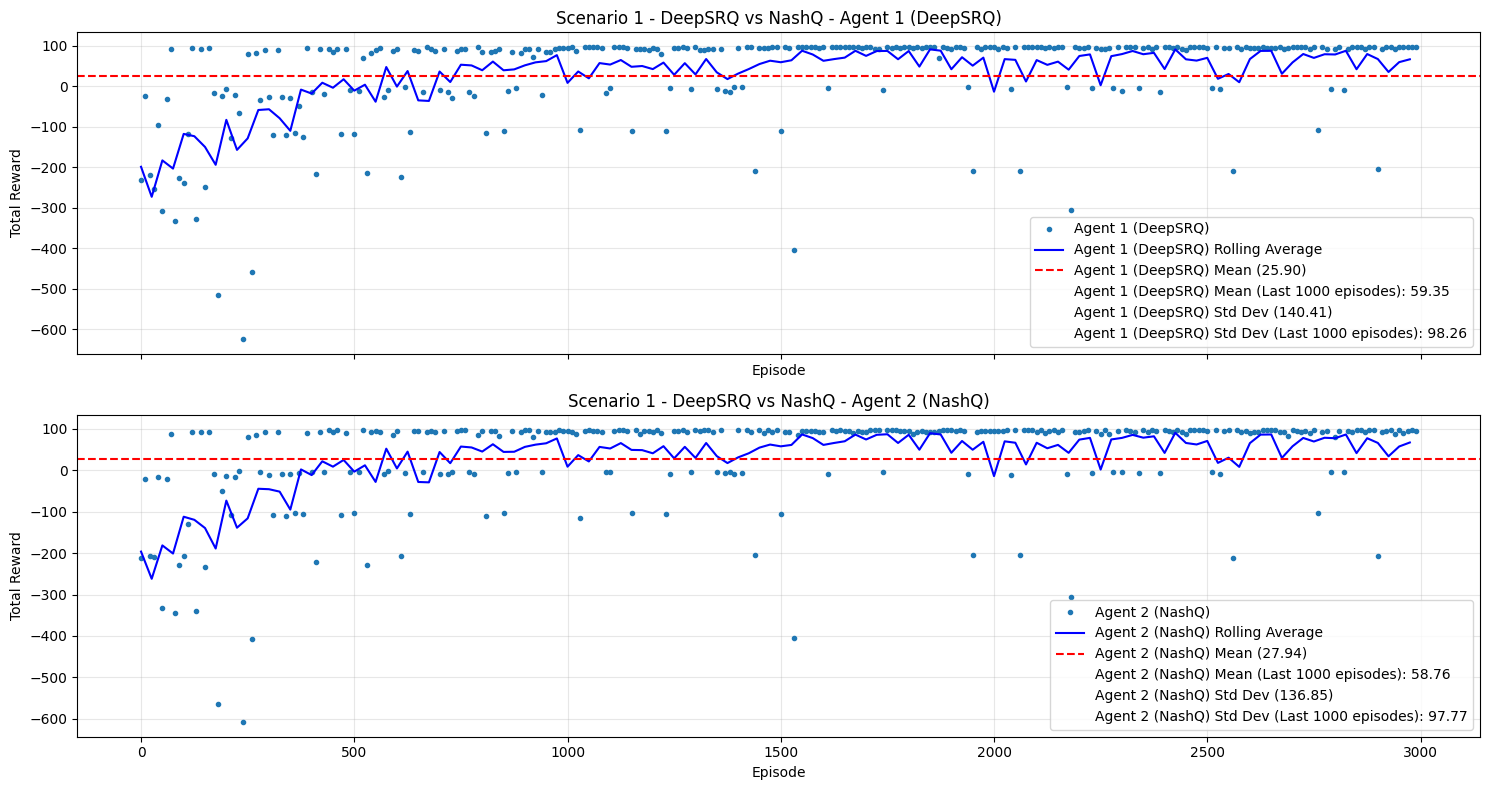

Saved stats to full_pair_comparison_runs/deep_srq_vs_nash_q/scenario1/deep_srq_exponential_eps1_vs_nashq_eps1_exponential_22127/training_stats.txt
Scenario 1 - DeepSRQ vs NashQ - deep_srq_exponential_eps1_vs_nashq_eps1_exponential_22127
Wall clock: 3228.455s (53.81 min)
Episode time:   count=3000, mean=1.075386s (1075386.12 us), min=0.304516s, max=8.157086s, std=0.903397s
SRE solve time: count=499480, mean=0.003406s (3406.19 us), min=0.001427s, max=0.268532s, std=0.002817s
Backend solve:  count=499480, mean=0.015099s (15099.07 us), min=0.007265s, max=1.004162s, std=0.006341s
  Agent 0 (deep_srq)
    SRE solve:  count=499480, mean=0.003406s (3406.19 us), min=0.001427s, max=0.268532s, std=0.002817s
    Backend:    count=499480, mean=0.015099s (15099.07 us), min=0.007265s, max=1.004162s, std=0.006341s
    Update:     count=39039, mean=0.043360s (43359.62 us), min=0.018464s, max=1.012319s, std=0.011750s
  Agent 1 (nashq)
    SRE solve:  count=0
    Backend:    count=0
    Update:     count

scenario1: deep_srq_vs_nashq: 100%|██████████| 3000/3000 [47:11<00:00,  1.06it/s] 


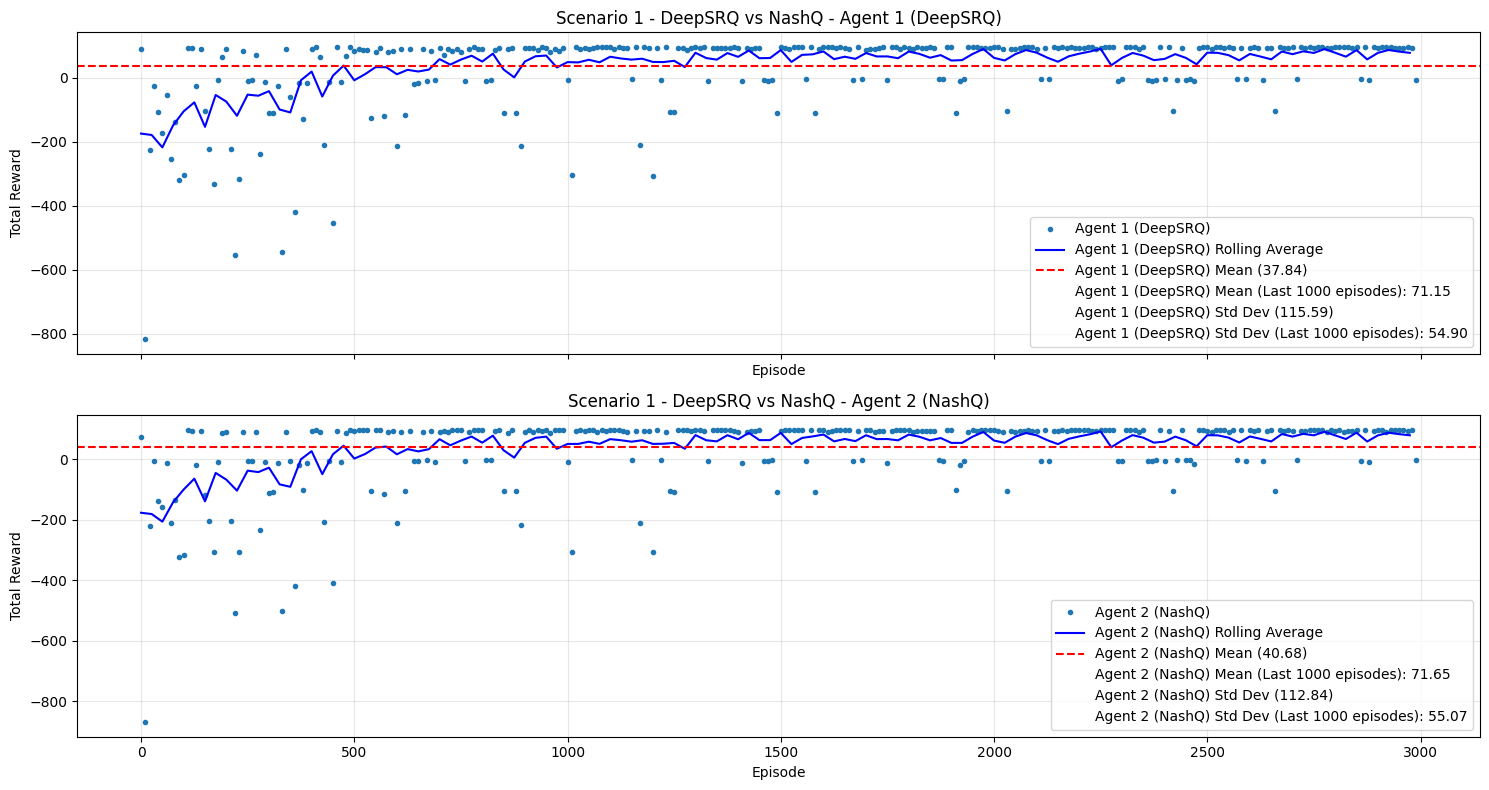

Saved stats to full_pair_comparison_runs/deep_srq_vs_nash_q/scenario1/deep_srq_constant_eps0.25_vs_nashq_eps0.25_constant_22225/training_stats.txt
Scenario 1 - DeepSRQ vs NashQ - deep_srq_constant_eps0.25_vs_nashq_eps0.25_constant_22225
Wall clock: 2911.996s (48.53 min)
Episode time:   count=3000, mean=0.969917s (969916.87 us), min=0.132734s, max=9.714403s, std=0.869337s
SRE solve time: count=439782, mean=0.003371s (3371.35 us), min=0.001546s, max=0.136366s, std=0.002947s
Backend solve:  count=439782, mean=0.015238s (15237.66 us), min=0.007347s, max=1.487665s, std=0.007653s
  Agent 0 (deep_srq)
    SRE solve:  count=439782, mean=0.003371s (3371.35 us), min=0.001546s, max=0.136366s, std=0.002947s
    Backend:    count=439782, mean=0.015238s (15237.66 us), min=0.007347s, max=1.487665s, std=0.007653s
    Update:     count=34135, mean=0.043712s (43712.48 us), min=0.020191s, max=1.506293s, std=0.020611s
  Agent 1 (nashq)
    SRE solve:  count=0
    Backend:    count=0
    Update:     count=

scenario1: deep_srq_vs_nashq: 100%|██████████| 3000/3000 [53:13<00:00,  1.06s/it] 


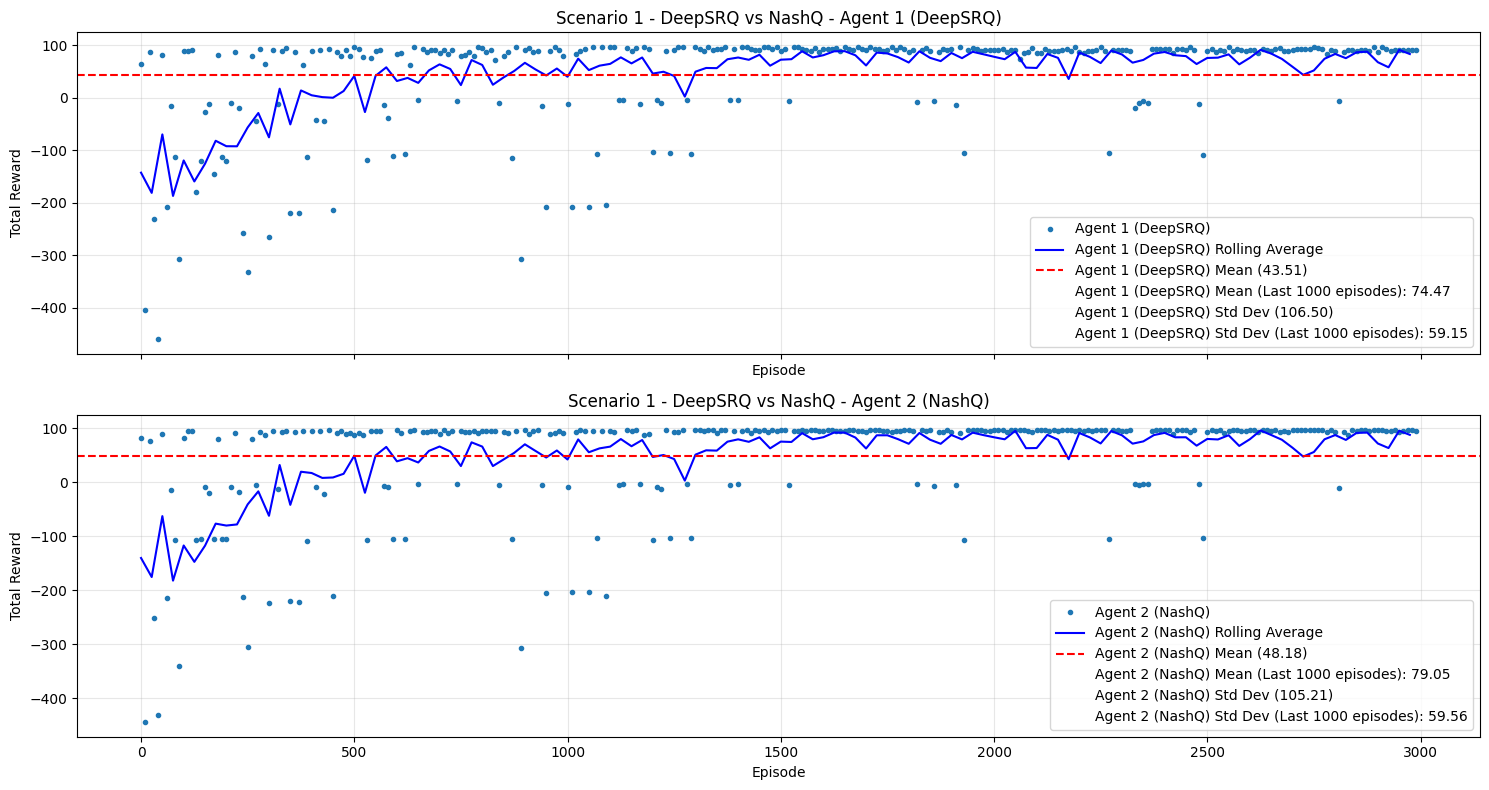

Saved stats to full_pair_comparison_runs/deep_srq_vs_nash_q/scenario1/deep_srq_constant_eps0.5_vs_nashq_eps0.5_constant_22226/training_stats.txt
Scenario 1 - DeepSRQ vs NashQ - deep_srq_constant_eps0.5_vs_nashq_eps0.5_constant_22226
Wall clock: 3274.318s (54.57 min)
Episode time:   count=3000, mean=1.090346s (1090346.08 us), min=0.273559s, max=11.466161s, std=0.800885s
SRE solve time: count=473298, mean=0.003874s (3874.39 us), min=0.001486s, max=1.159220s, std=0.003892s
Backend solve:  count=473298, mean=0.016538s (16538.06 us), min=0.007377s, max=1.631450s, std=0.009159s
  Agent 0 (deep_srq)
    SRE solve:  count=473298, mean=0.003874s (3874.39 us), min=0.001486s, max=1.159220s, std=0.003892s
    Backend:    count=473298, mean=0.016538s (16538.06 us), min=0.007377s, max=1.631450s, std=0.009159s
    Update:     count=37482, mean=0.047226s (47226.11 us), min=0.019846s, max=1.642689s, std=0.020374s
  Agent 1 (nashq)
    SRE solve:  count=0
    Backend:    count=0
    Update:     count=38

scenario1: deep_srq_vs_nashq: 100%|██████████| 3000/3000 [51:12<00:00,  1.02s/it] 


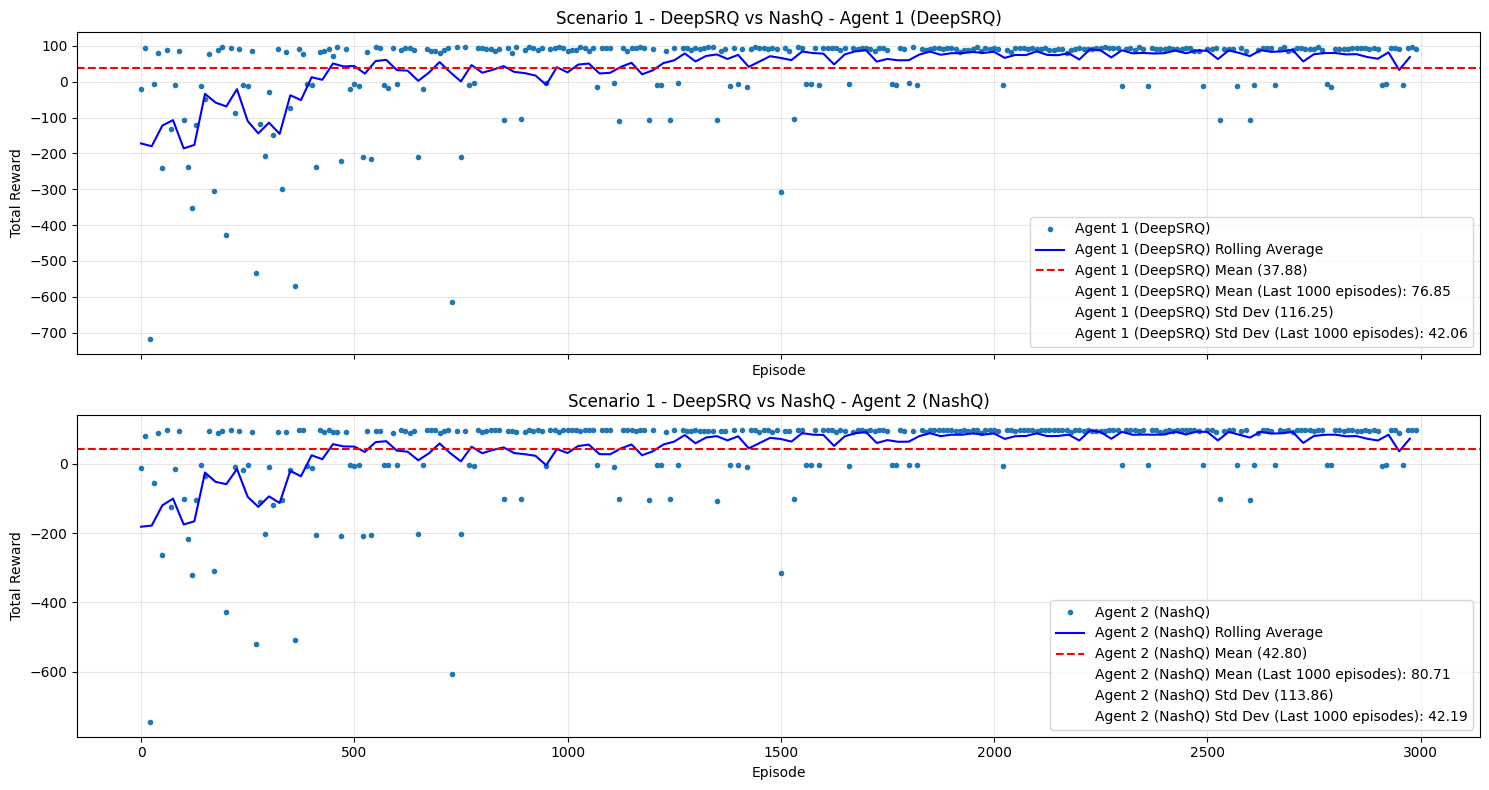

Saved stats to full_pair_comparison_runs/deep_srq_vs_nash_q/scenario1/deep_srq_constant_eps1_vs_nashq_eps1_constant_22227/training_stats.txt
Scenario 1 - DeepSRQ vs NashQ - deep_srq_constant_eps1_vs_nashq_eps1_constant_22227
Wall clock: 3143.147s (52.39 min)
Episode time:   count=3000, mean=1.046943s (1046942.57 us), min=0.209286s, max=8.590186s, std=0.807438s
SRE solve time: count=487185, mean=0.003248s (3247.89 us), min=0.001374s, max=0.121589s, std=0.002620s
Backend solve:  count=487185, mean=0.014225s (14224.91 us), min=0.006907s, max=1.701134s, std=0.006135s
  Agent 0 (deep_srq)
    SRE solve:  count=487185, mean=0.003248s (3247.89 us), min=0.001374s, max=0.121589s, std=0.002620s
    Backend:    count=487185, mean=0.014225s (14224.91 us), min=0.006907s, max=1.701134s, std=0.006135s
    Update:     count=38808, mean=0.040857s (40857.32 us), min=0.018868s, max=1.709744s, std=0.013167s
  Agent 1 (nashq)
    SRE solve:  count=0
    Backend:    count=0
    Update:     count=39807, mean

scenario2: deep_srq_vs_nashq: 100%|██████████| 3000/3000 [50:32<00:00,  1.01s/it] 


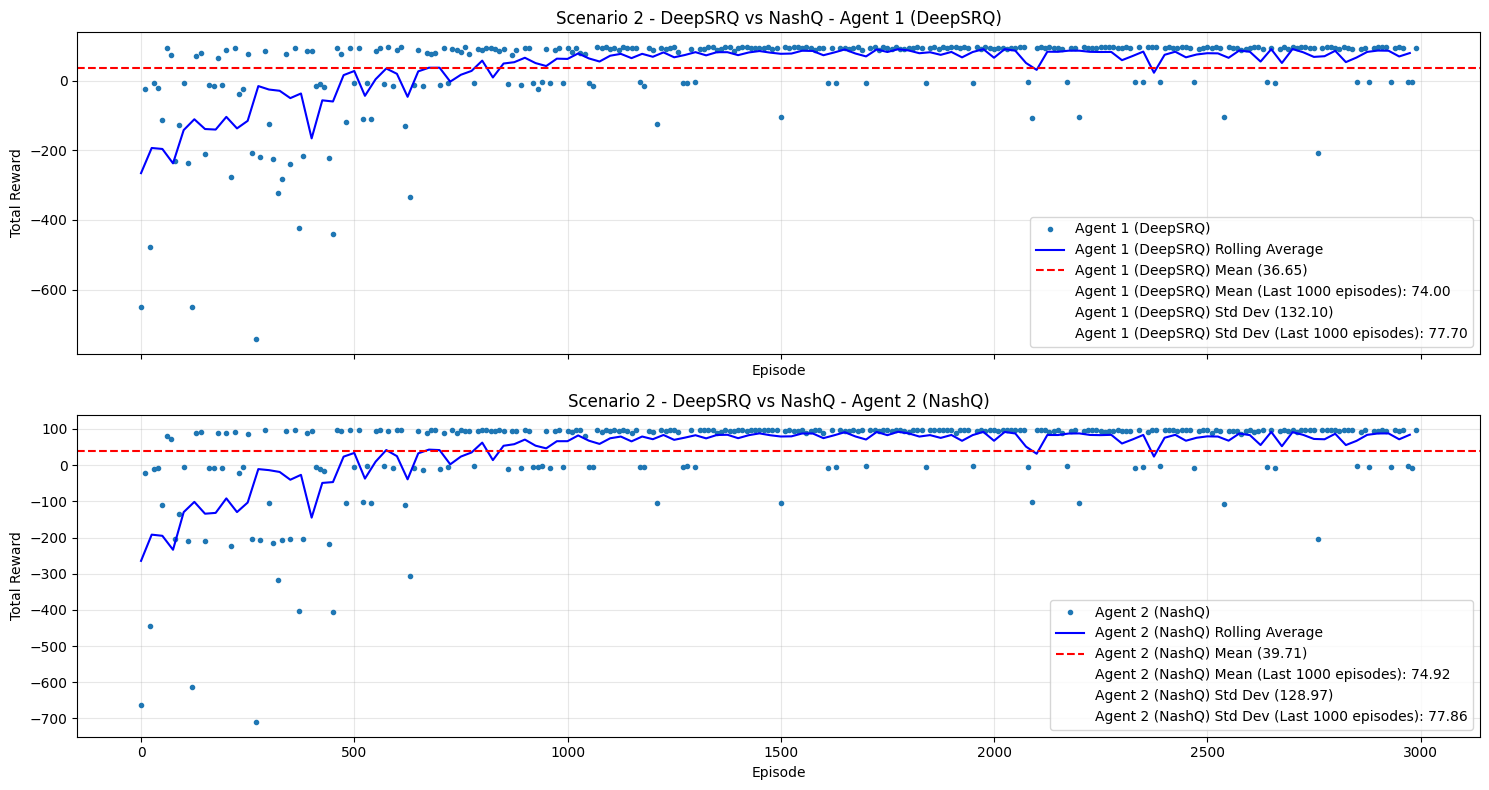

Saved stats to full_pair_comparison_runs/deep_srq_vs_nash_q/scenario2/deep_srq_linear_eps0.25_vs_nashq_eps0.25_linear_23025/training_stats.txt
Scenario 2 - DeepSRQ vs NashQ - deep_srq_linear_eps0.25_vs_nashq_eps0.25_linear_23025
Wall clock: 3094.954s (51.58 min)
Episode time:   count=3000, mean=1.030865s (1030864.98 us), min=0.327357s, max=10.372210s, std=0.919485s
SRE solve time: count=449478, mean=0.003585s (3585.37 us), min=0.001630s, max=0.173004s, std=0.003320s
Backend solve:  count=449478, mean=0.016216s (16215.76 us), min=0.007891s, max=1.901807s, std=0.009129s
  Agent 0 (deep_srq)
    SRE solve:  count=449478, mean=0.003585s (3585.37 us), min=0.001630s, max=0.173004s, std=0.003320s
    Backend:    count=449478, mean=0.016216s (16215.76 us), min=0.007891s, max=1.901807s, std=0.009129s
    Update:     count=34688, mean=0.045973s (45972.65 us), min=0.020890s, max=1.911113s, std=0.024892s
  Agent 1 (nashq)
    SRE solve:  count=0
    Backend:    count=0
    Update:     count=35687,

scenario2: deep_srq_vs_nashq: 100%|██████████| 3000/3000 [48:33<00:00,  1.03it/s] 


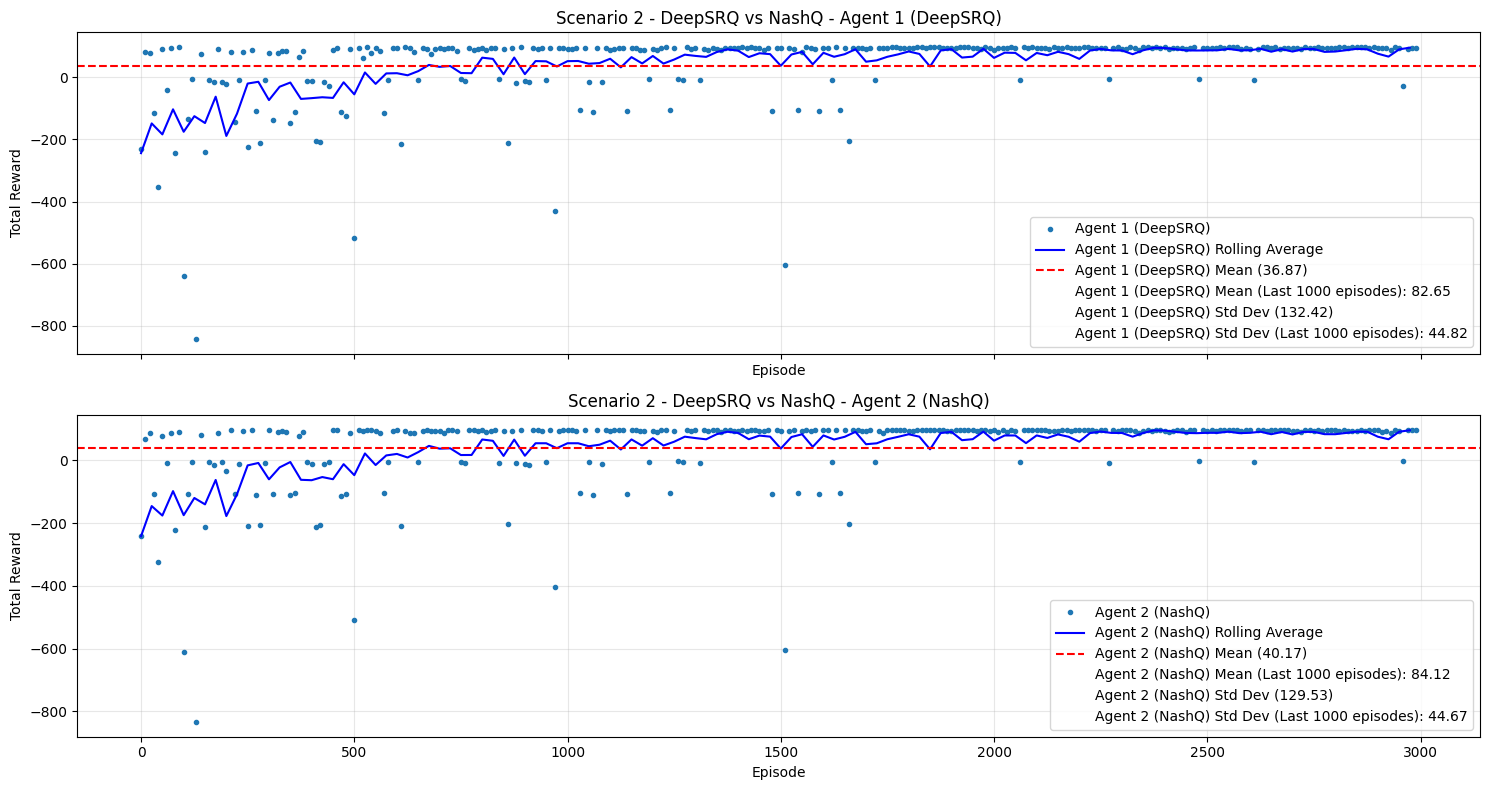

Saved stats to full_pair_comparison_runs/deep_srq_vs_nash_q/scenario2/deep_srq_linear_eps0.5_vs_nashq_eps0.5_linear_23026/training_stats.txt
Scenario 2 - DeepSRQ vs NashQ - deep_srq_linear_eps0.5_vs_nashq_eps0.5_linear_23026
Wall clock: 2966.697s (49.44 min)
Episode time:   count=3000, mean=0.988143s (988142.89 us), min=0.217855s, max=12.197722s, std=0.829853s
SRE solve time: count=449555, mean=0.003558s (3557.57 us), min=0.001402s, max=0.137631s, std=0.003125s
Backend solve:  count=449555, mean=0.015812s (15812.23 us), min=0.007485s, max=2.063299s, std=0.007447s
  Agent 0 (deep_srq)
    SRE solve:  count=449555, mean=0.003558s (3557.57 us), min=0.001402s, max=0.137631s, std=0.003125s
    Backend:    count=449555, mean=0.015812s (15812.23 us), min=0.007485s, max=2.063299s, std=0.007447s
    Update:     count=34014, mean=0.046100s (46099.97 us), min=0.020355s, max=2.074629s, std=0.017185s
  Agent 1 (nashq)
    SRE solve:  count=0
    Backend:    count=0
    Update:     count=35013, mean

scenario2: deep_srq_vs_nashq: 100%|██████████| 3000/3000 [50:11<00:00,  1.00s/it] 


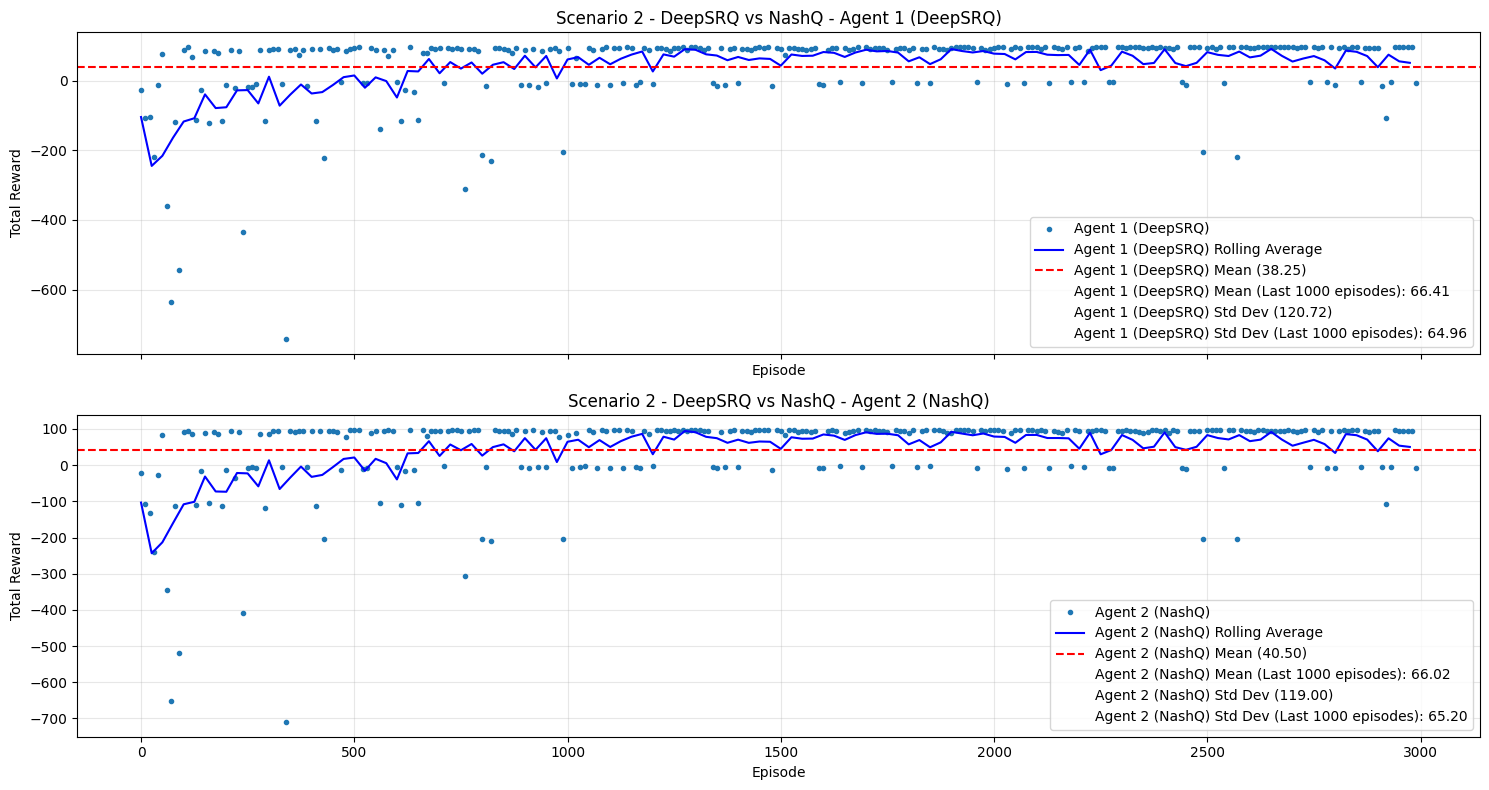

Saved stats to full_pair_comparison_runs/deep_srq_vs_nash_q/scenario2/deep_srq_linear_eps1_vs_nashq_eps1_linear_23027/training_stats.txt
Scenario 2 - DeepSRQ vs NashQ - deep_srq_linear_eps1_vs_nashq_eps1_linear_23027
Wall clock: 3058.621s (50.98 min)
Episode time:   count=3000, mean=1.018780s (1018779.73 us), min=0.151757s, max=11.823591s, std=0.777879s
SRE solve time: count=472132, mean=0.003380s (3379.80 us), min=0.001430s, max=0.092249s, std=0.003045s
Backend solve:  count=472132, mean=0.015040s (15040.03 us), min=0.007420s, max=0.565935s, std=0.006407s
  Agent 0 (deep_srq)
    SRE solve:  count=472132, mean=0.003380s (3379.80 us), min=0.001430s, max=0.092249s, std=0.003045s
    Backend:    count=472132, mean=0.015040s (15040.03 us), min=0.007420s, max=0.565935s, std=0.006407s
    Update:     count=34812, mean=0.044699s (44699.47 us), min=0.020700s, max=0.587388s, std=0.012195s
  Agent 1 (nashq)
    SRE solve:  count=0
    Backend:    count=0
    Update:     count=35811, mean=0.0000

scenario2: deep_srq_vs_nashq: 100%|██████████| 3000/3000 [59:57<00:00,  1.20s/it]  


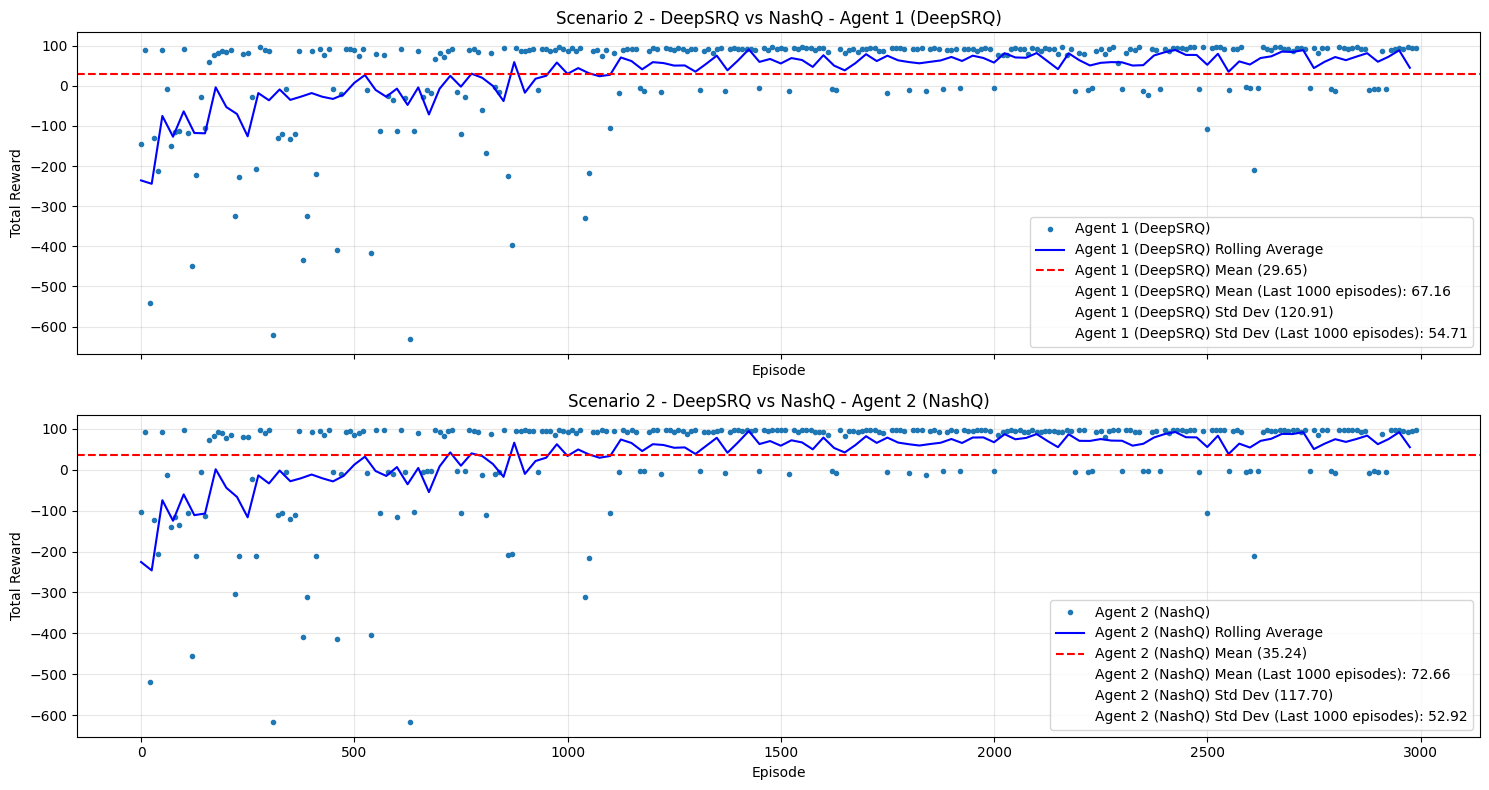

Saved stats to full_pair_comparison_runs/deep_srq_vs_nash_q/scenario2/deep_srq_exponential_eps0.25_vs_nashq_eps0.25_exponential_23125/training_stats.txt
Scenario 2 - DeepSRQ vs NashQ - deep_srq_exponential_eps0.25_vs_nashq_eps0.25_exponential_23125
Wall clock: 3600.850s (60.01 min)
Episode time:   count=3000, mean=1.199563s (1199563.26 us), min=0.117855s, max=8.598400s, std=0.910809s
SRE solve time: count=527403, mean=0.003802s (3801.92 us), min=0.001521s, max=0.198633s, std=0.003479s
Backend solve:  count=527403, mean=0.016026s (16025.74 us), min=0.007342s, max=1.497652s, std=0.007237s
  Agent 0 (deep_srq)
    SRE solve:  count=527403, mean=0.003802s (3801.92 us), min=0.001521s, max=0.198633s, std=0.003479s
    Backend:    count=527403, mean=0.016026s (16025.74 us), min=0.007342s, max=1.497652s, std=0.007237s
    Update:     count=42771, mean=0.044232s (44232.44 us), min=0.020279s, max=1.504770s, std=0.013465s
  Agent 1 (nashq)
    SRE solve:  count=0
    Backend:    count=0
    Updat

scenario2: deep_srq_vs_nashq: 100%|██████████| 3000/3000 [51:55<00:00,  1.04s/it] 


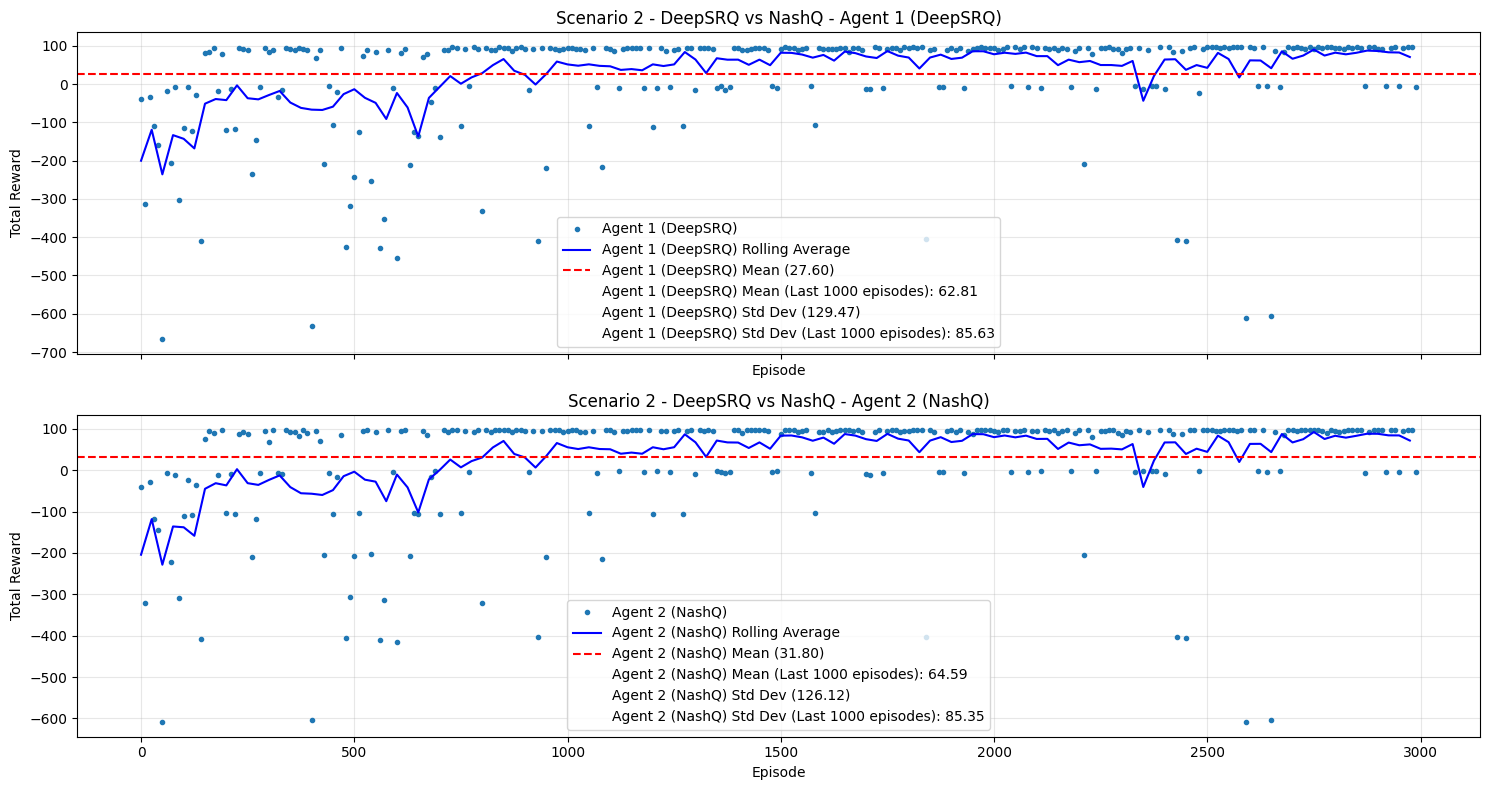

Saved stats to full_pair_comparison_runs/deep_srq_vs_nash_q/scenario2/deep_srq_exponential_eps0.5_vs_nashq_eps0.5_exponential_23126/training_stats.txt
Scenario 2 - DeepSRQ vs NashQ - deep_srq_exponential_eps0.5_vs_nashq_eps0.5_exponential_23126
Wall clock: 3115.231s (51.92 min)
Episode time:   count=3000, mean=1.037662s (1037661.66 us), min=0.210975s, max=8.125074s, std=0.872262s
SRE solve time: count=477264, mean=0.003345s (3345.05 us), min=0.001413s, max=0.177847s, std=0.002827s
Backend solve:  count=477264, mean=0.014936s (14936.28 us), min=0.007156s, max=1.599852s, std=0.006232s
  Agent 0 (deep_srq)
    SRE solve:  count=477264, mean=0.003345s (3345.05 us), min=0.001413s, max=0.177847s, std=0.002827s
    Backend:    count=477264, mean=0.014936s (14936.28 us), min=0.007156s, max=1.599852s, std=0.006232s
    Update:     count=37227, mean=0.042308s (42307.86 us), min=0.019434s, max=1.606966s, std=0.013134s
  Agent 1 (nashq)
    SRE solve:  count=0
    Backend:    count=0
    Update:  

scenario2: deep_srq_vs_nashq: 100%|██████████| 3000/3000 [42:55<00:00,  1.16it/s] 


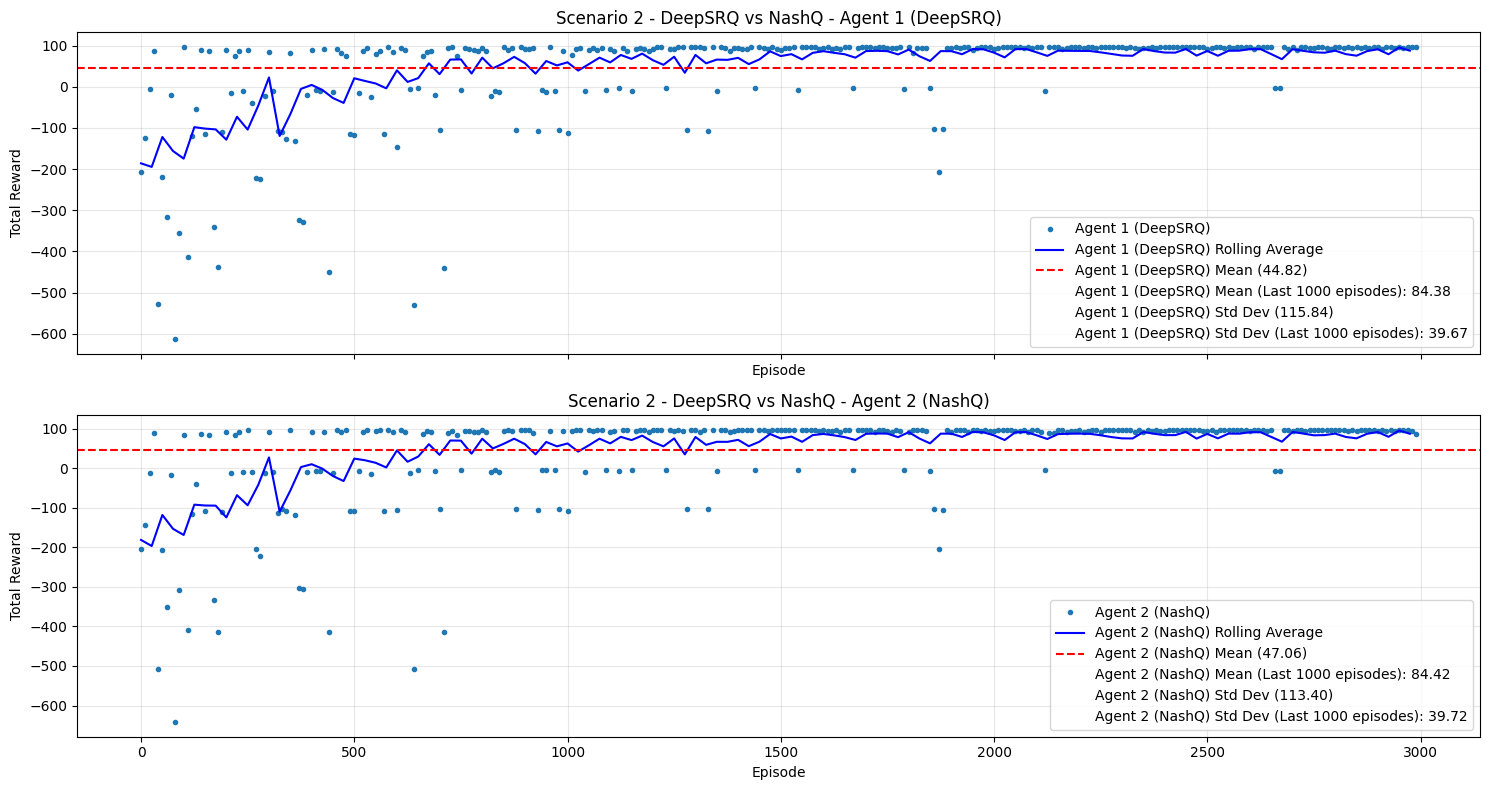

Saved stats to full_pair_comparison_runs/deep_srq_vs_nash_q/scenario2/deep_srq_exponential_eps1_vs_nashq_eps1_exponential_23127/training_stats.txt
Scenario 2 - DeepSRQ vs NashQ - deep_srq_exponential_eps1_vs_nashq_eps1_exponential_23127
Wall clock: 2575.606s (42.93 min)
Episode time:   count=3000, mean=0.857817s (857816.99 us), min=0.120075s, max=10.699711s, std=0.822818s
SRE solve time: count=415874, mean=0.003220s (3219.67 us), min=0.001427s, max=0.119497s, std=0.002649s
Backend solve:  count=415874, mean=0.014539s (14538.70 us), min=0.007422s, max=1.515687s, std=0.006401s
  Agent 0 (deep_srq)
    SRE solve:  count=415874, mean=0.003220s (3219.67 us), min=0.001427s, max=0.119497s, std=0.002649s
    Backend:    count=415874, mean=0.014539s (14538.70 us), min=0.007422s, max=1.515687s, std=0.006401s
    Update:     count=31421, mean=0.042756s (42756.38 us), min=0.019917s, max=1.538237s, std=0.013524s
  Agent 1 (nashq)
    SRE solve:  count=0
    Backend:    count=0
    Update:     count

scenario2: deep_srq_vs_nashq: 100%|██████████| 3000/3000 [48:57<00:00,  1.02it/s] 


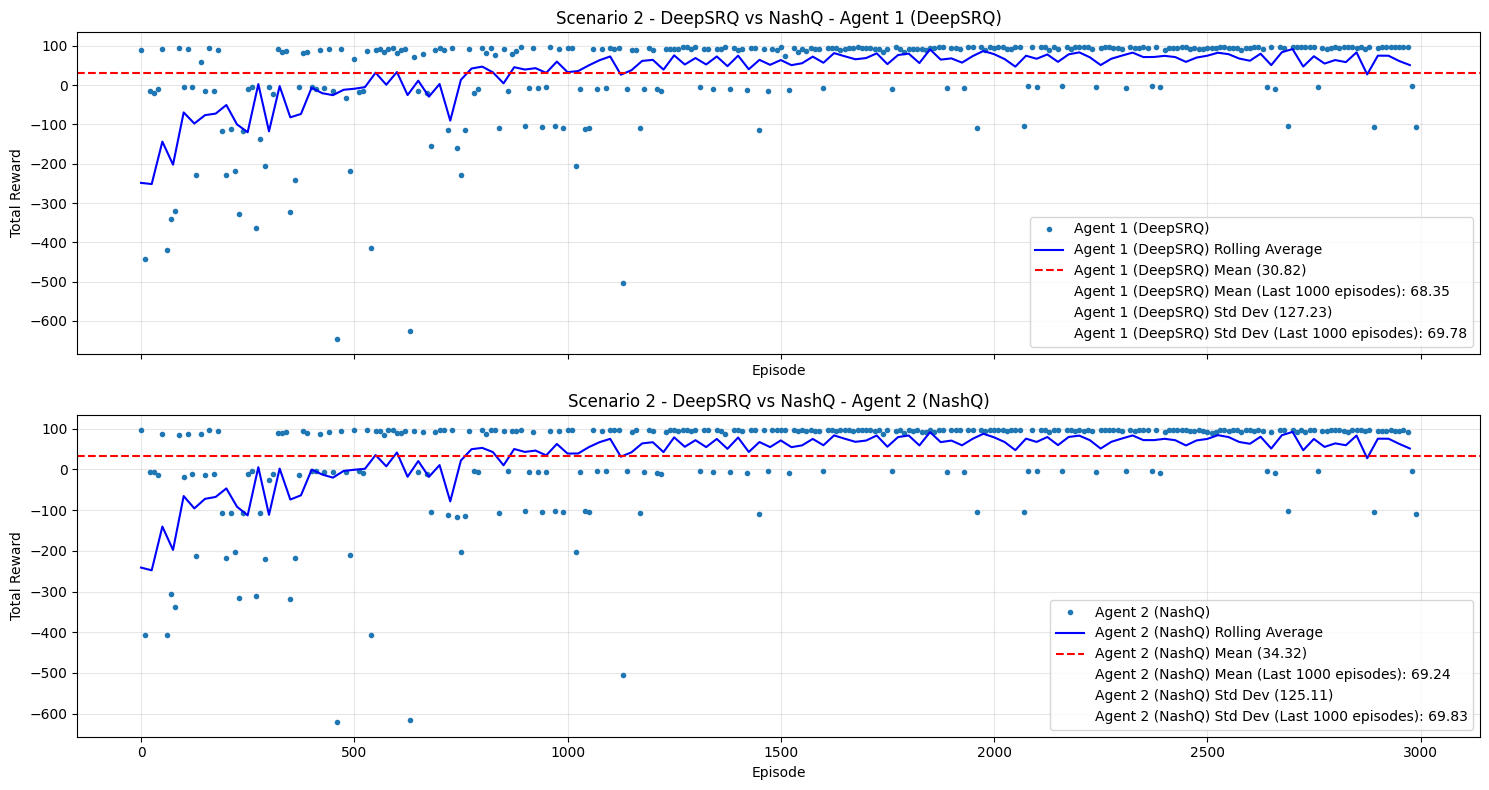

Saved stats to full_pair_comparison_runs/deep_srq_vs_nash_q/scenario2/deep_srq_constant_eps0.25_vs_nashq_eps0.25_constant_23225/training_stats.txt
Scenario 2 - DeepSRQ vs NashQ - deep_srq_constant_eps0.25_vs_nashq_eps0.25_constant_23225
Wall clock: 2937.090s (48.95 min)
Episode time:   count=3000, mean=0.978294s (978294.37 us), min=0.101860s, max=10.526364s, std=0.784664s
SRE solve time: count=440801, mean=0.003472s (3471.99 us), min=0.001484s, max=0.136818s, std=0.003129s
Backend solve:  count=440801, mean=0.015196s (15196.08 us), min=0.007202s, max=1.625490s, std=0.008200s
  Agent 0 (deep_srq)
    SRE solve:  count=440801, mean=0.003472s (3471.99 us), min=0.001484s, max=0.136818s, std=0.003129s
    Backend:    count=440801, mean=0.015196s (15196.08 us), min=0.007202s, max=1.625490s, std=0.008200s
    Update:     count=34260, mean=0.043995s (43994.79 us), min=0.021150s, max=1.649357s, std=0.020699s
  Agent 1 (nashq)
    SRE solve:  count=0
    Backend:    count=0
    Update:     count

scenario2: deep_srq_vs_nashq: 100%|██████████| 3000/3000 [46:10<00:00,  1.08it/s]  


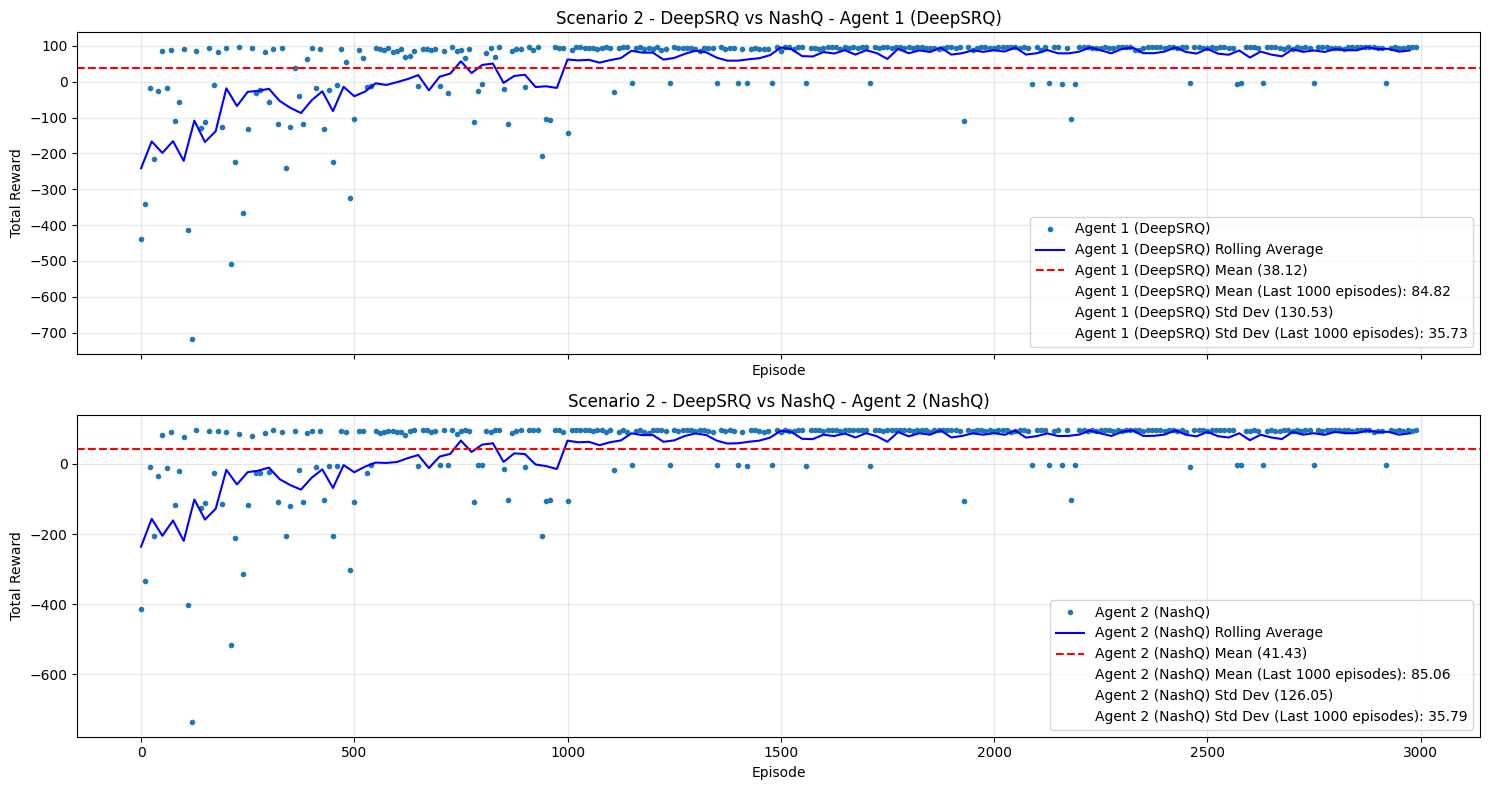

Saved stats to full_pair_comparison_runs/deep_srq_vs_nash_q/scenario2/deep_srq_constant_eps0.5_vs_nashq_eps0.5_constant_23226/training_stats.txt
Scenario 2 - DeepSRQ vs NashQ - deep_srq_constant_eps0.5_vs_nashq_eps0.5_constant_23226
Wall clock: 2770.373s (46.17 min)
Episode time:   count=3000, mean=0.922730s (922729.53 us), min=0.234252s, max=8.912306s, std=0.904598s
SRE solve time: count=450356, mean=0.003229s (3229.13 us), min=0.001386s, max=0.089084s, std=0.002572s
Backend solve:  count=450356, mean=0.014458s (14457.73 us), min=0.007516s, max=0.763562s, std=0.005910s
  Agent 0 (deep_srq)
    SRE solve:  count=450356, mean=0.003229s (3229.13 us), min=0.001386s, max=0.089084s, std=0.002572s
    Backend:    count=450356, mean=0.014458s (14457.73 us), min=0.007516s, max=0.763562s, std=0.005910s
    Update:     count=35156, mean=0.041679s (41679.12 us), min=0.018332s, max=0.772220s, std=0.010708s
  Agent 1 (nashq)
    SRE solve:  count=0
    Backend:    count=0
    Update:     count=3615

scenario2: deep_srq_vs_nashq: 100%|██████████| 3000/3000 [45:35<00:00,  1.10it/s] 


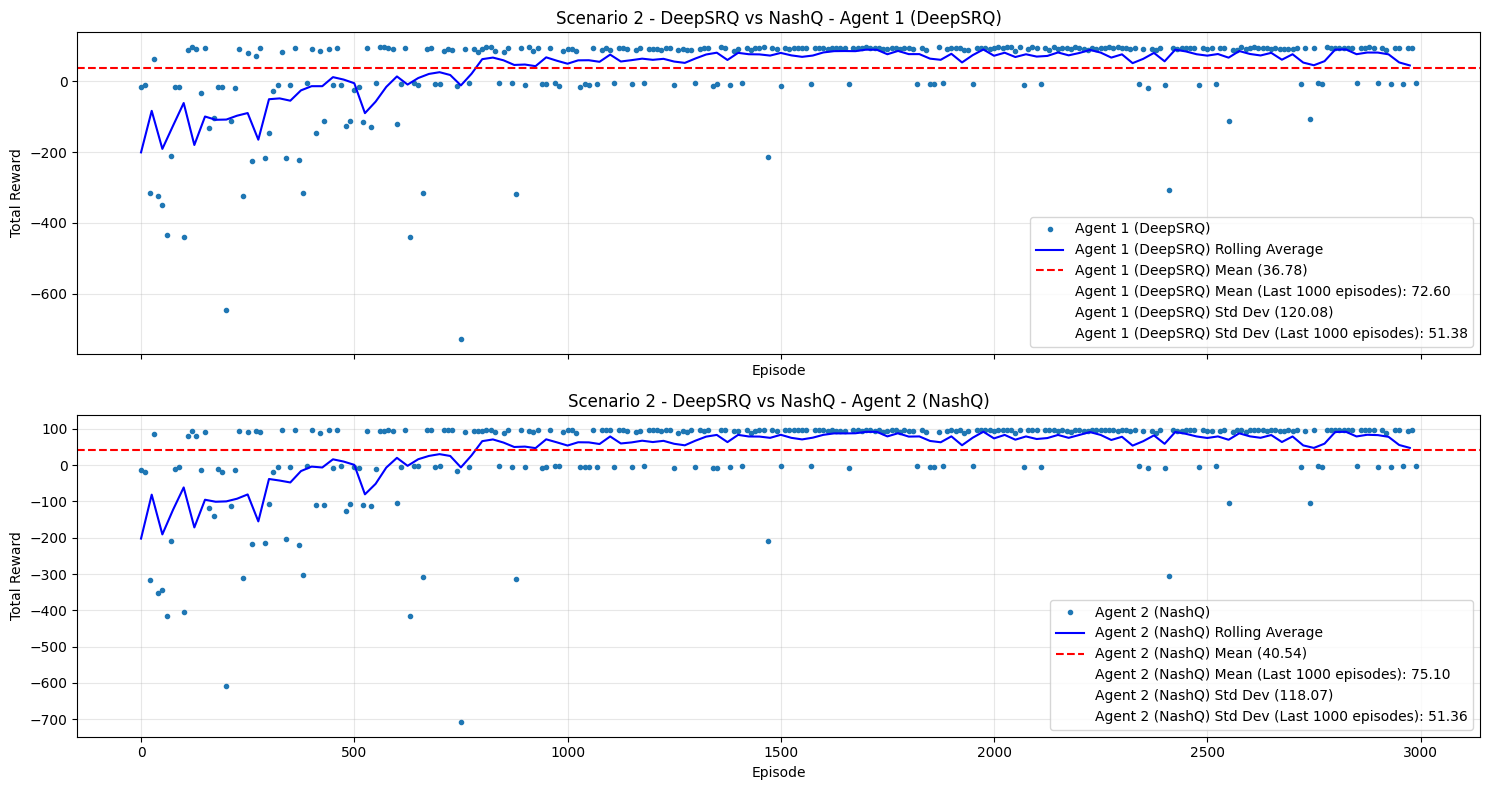

Saved stats to full_pair_comparison_runs/deep_srq_vs_nash_q/scenario2/deep_srq_constant_eps1_vs_nashq_eps1_constant_23227/training_stats.txt
Scenario 2 - DeepSRQ vs NashQ - deep_srq_constant_eps1_vs_nashq_eps1_constant_23227
Wall clock: 2735.284s (45.59 min)
Episode time:   count=3000, mean=0.911037s (911036.87 us), min=0.110103s, max=7.248094s, std=0.738932s
SRE solve time: count=463883, mean=0.002859s (2859.12 us), min=0.001229s, max=0.098102s, std=0.002388s
Backend solve:  count=463883, mean=0.013016s (13015.52 us), min=0.007156s, max=1.078168s, std=0.005122s
  Agent 0 (deep_srq)
    SRE solve:  count=463883, mean=0.002859s (2859.12 us), min=0.001229s, max=0.098102s, std=0.002388s
    Backend:    count=463883, mean=0.013016s (13015.52 us), min=0.007156s, max=1.078168s, std=0.005122s
    Update:     count=35529, mean=0.037772s (37771.88 us), min=0.017686s, max=1.086713s, std=0.012098s
  Agent 1 (nashq)
    SRE solve:  count=0
    Backend:    count=0
    Update:     count=36528, mean=

scenario3: deep_srq_vs_nashq: 100%|██████████| 3000/3000 [1:24:20<00:00,  1.69s/it]


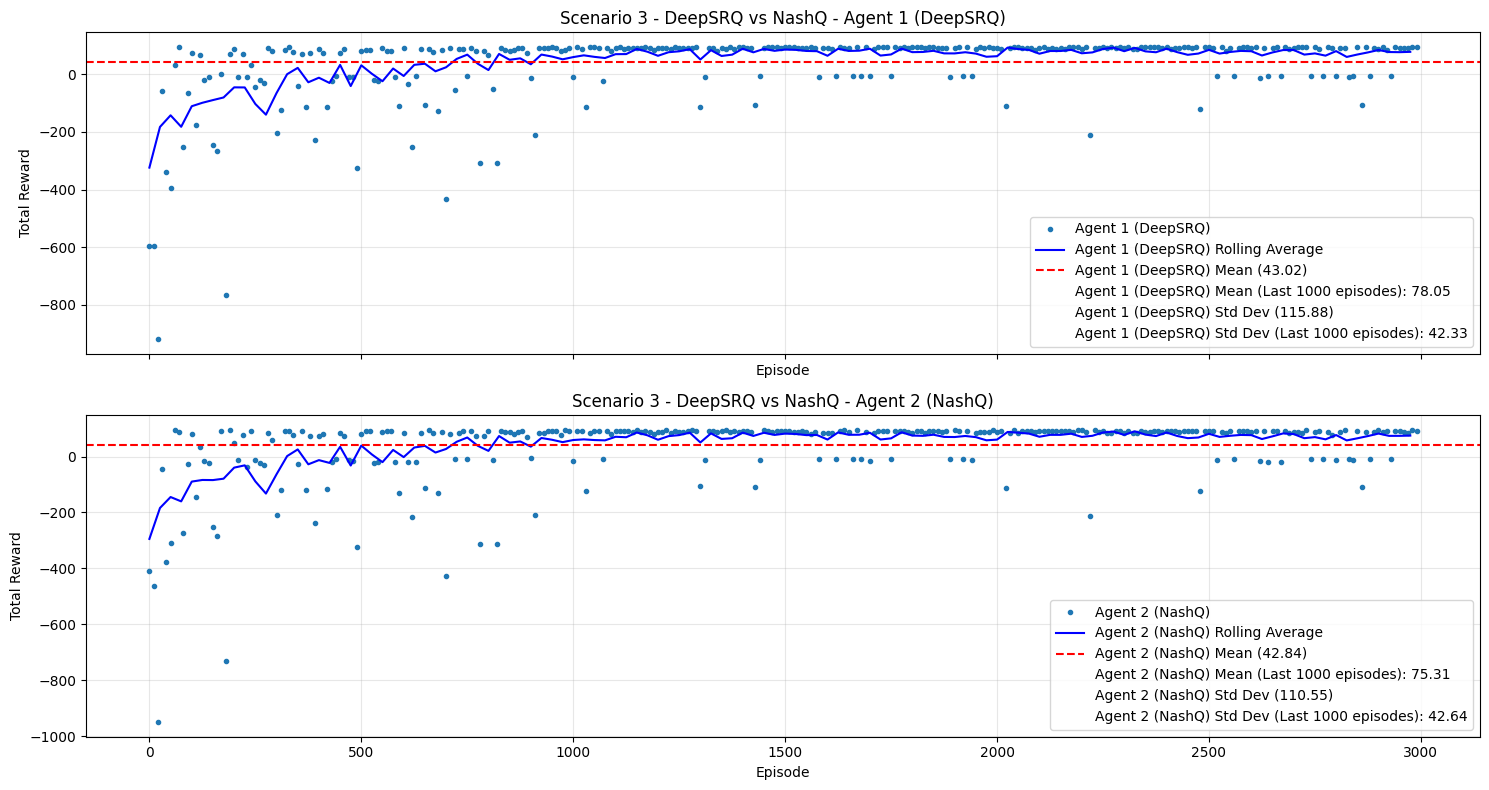

Saved stats to full_pair_comparison_runs/deep_srq_vs_nash_q/scenario3/deep_srq_linear_eps0.25_vs_nashq_eps0.25_linear_24025/training_stats.txt
Scenario 3 - DeepSRQ vs NashQ - deep_srq_linear_eps0.25_vs_nashq_eps0.25_linear_24025
Wall clock: 5060.281s (84.34 min)
Episode time:   count=3000, mean=1.686001s (1686001.16 us), min=0.550443s, max=11.584548s, std=1.488619s
SRE solve time: count=816197, mean=0.002909s (2909.21 us), min=0.001407s, max=0.103309s, std=0.002457s
Backend solve:  count=816197, mean=0.014058s (14058.45 us), min=0.007164s, max=1.637581s, std=0.006804s
  Agent 0 (deep_srq)
    SRE solve:  count=816197, mean=0.002909s (2909.21 us), min=0.001407s, max=0.103309s, std=0.002457s
    Backend:    count=816197, mean=0.014058s (14058.45 us), min=0.007164s, max=1.637581s, std=0.006804s
    Update:     count=54691, mean=0.044238s (44238.23 us), min=0.023815s, max=1.658851s, std=0.018596s
  Agent 1 (nashq)
    SRE solve:  count=0
    Backend:    count=0
    Update:     count=55690,

scenario3: deep_srq_vs_nashq: 100%|██████████| 3000/3000 [1:24:18<00:00,  1.69s/it]


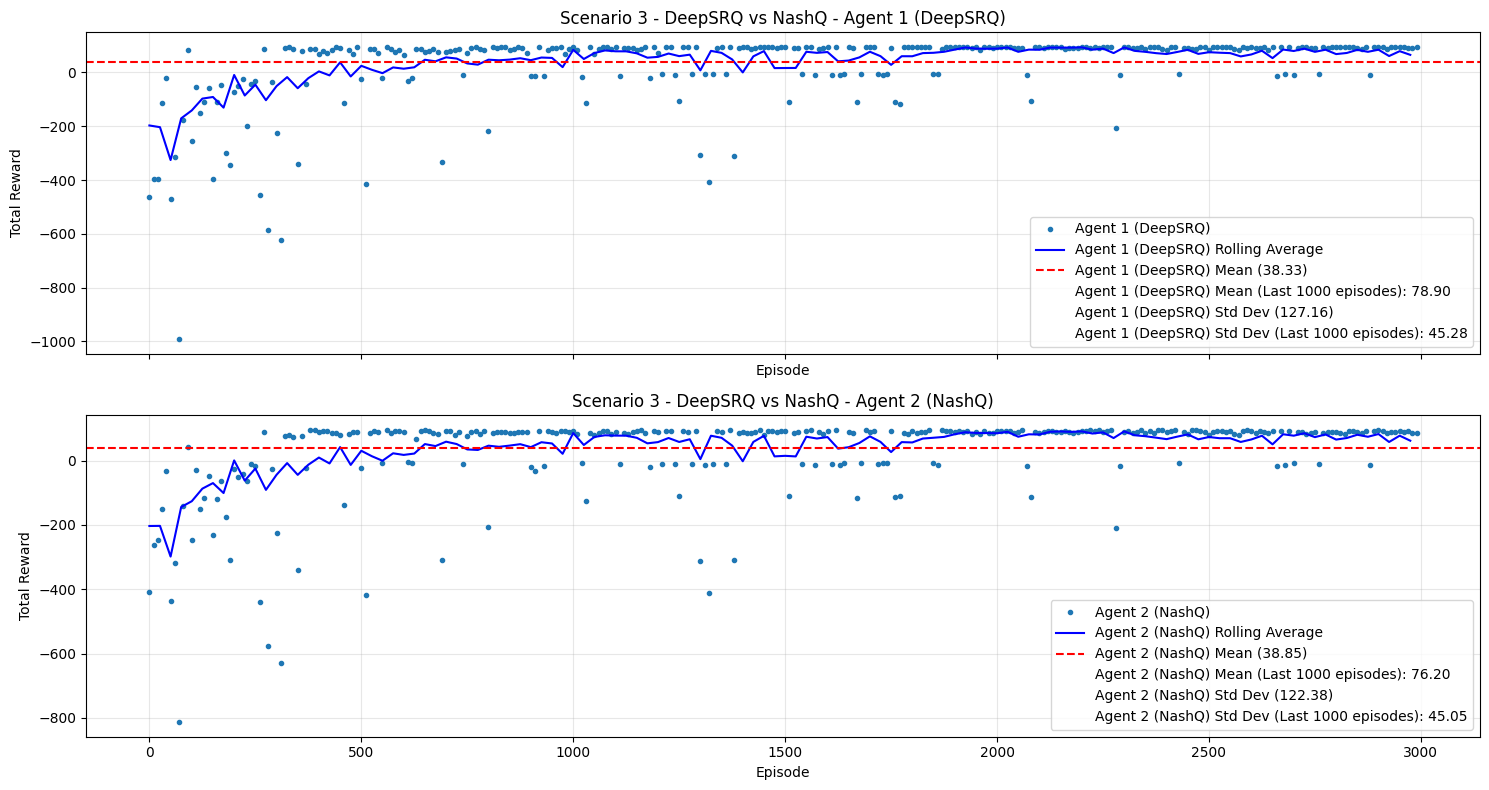

Saved stats to full_pair_comparison_runs/deep_srq_vs_nash_q/scenario3/deep_srq_linear_eps0.5_vs_nashq_eps0.5_linear_24026/training_stats.txt
Scenario 3 - DeepSRQ vs NashQ - deep_srq_linear_eps0.5_vs_nashq_eps0.5_linear_24026
Wall clock: 5059.051s (84.32 min)
Episode time:   count=3000, mean=1.685587s (1685586.82 us), min=0.426658s, max=12.201431s, std=1.493023s
SRE solve time: count=831434, mean=0.002786s (2785.80 us), min=0.001348s, max=0.089485s, std=0.002225s
Backend solve:  count=831434, mean=0.013705s (13704.90 us), min=0.006982s, max=1.201115s, std=0.005566s
  Agent 0 (deep_srq)
    SRE solve:  count=831434, mean=0.002786s (2785.80 us), min=0.001348s, max=0.089485s, std=0.002225s
    Backend:    count=831434, mean=0.013705s (13704.90 us), min=0.006982s, max=1.201115s, std=0.005566s
    Update:     count=55723, mean=0.042751s (42751.09 us), min=0.023778s, max=1.210633s, std=0.013047s
  Agent 1 (nashq)
    SRE solve:  count=0
    Backend:    count=0
    Update:     count=56722, mea

scenario3: deep_srq_vs_nashq: 100%|██████████| 3000/3000 [1:27:10<00:00,  1.74s/it]


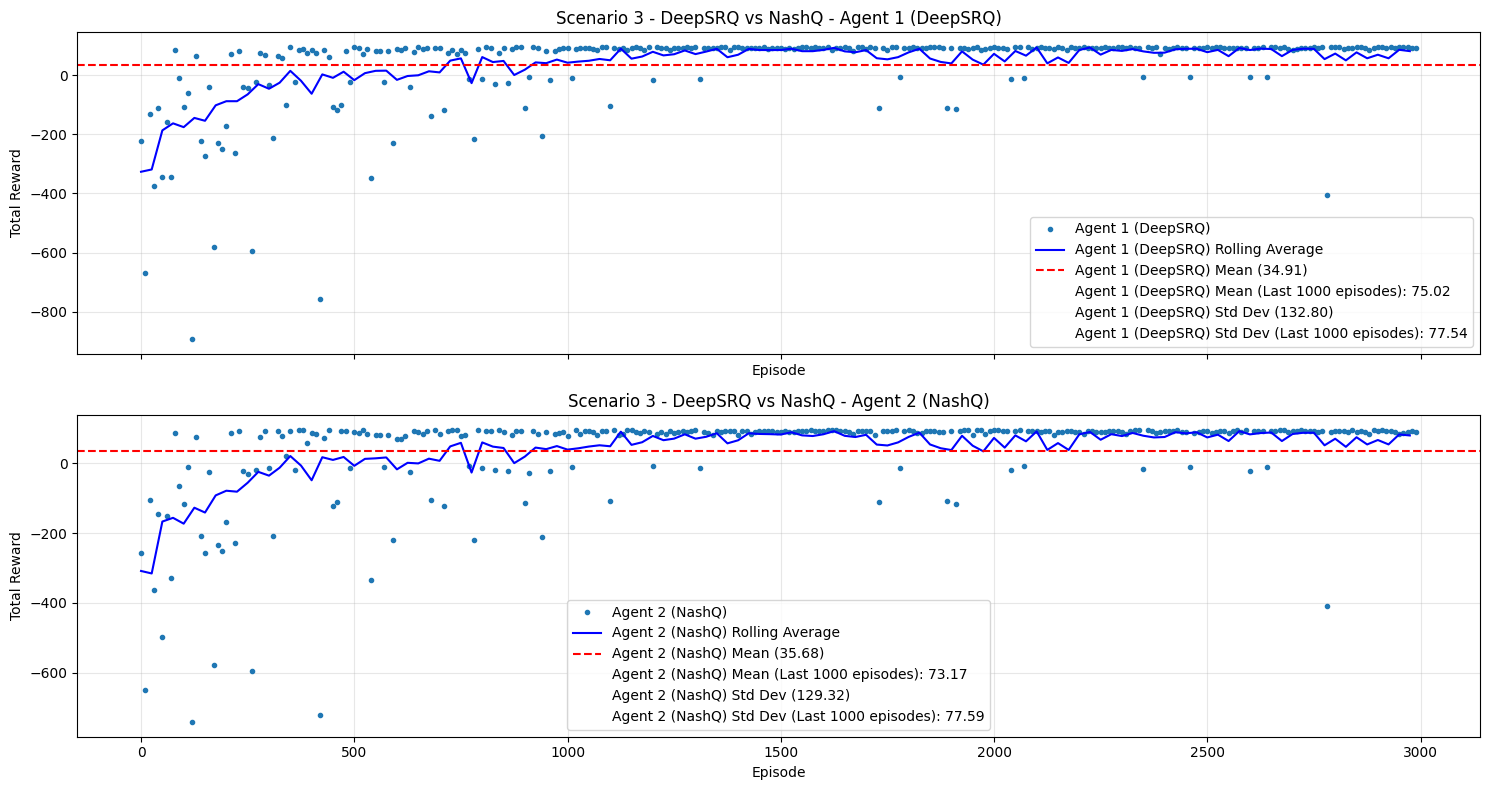

Saved stats to full_pair_comparison_runs/deep_srq_vs_nash_q/scenario3/deep_srq_linear_eps1_vs_nashq_eps1_linear_24027/training_stats.txt
Scenario 3 - DeepSRQ vs NashQ - deep_srq_linear_eps1_vs_nashq_eps1_linear_24027
Wall clock: 5230.984s (87.18 min)
Episode time:   count=3000, mean=1.742849s (1742849.14 us), min=0.515276s, max=12.656035s, std=1.589163s
SRE solve time: count=854909, mean=0.002804s (2804.14 us), min=0.001301s, max=0.888866s, std=0.002578s
Backend solve:  count=854909, mean=0.013738s (13737.51 us), min=0.007044s, max=1.420107s, std=0.006624s
  Agent 0 (deep_srq)
    SRE solve:  count=854909, mean=0.002804s (2804.14 us), min=0.001301s, max=0.888866s, std=0.002578s
    Backend:    count=854909, mean=0.013738s (13737.51 us), min=0.007044s, max=1.420107s, std=0.006624s
    Update:     count=56808, mean=0.043354s (43354.13 us), min=0.022902s, max=1.430195s, std=0.017972s
  Agent 1 (nashq)
    SRE solve:  count=0
    Backend:    count=0
    Update:     count=57807, mean=0.0000

scenario3: deep_srq_vs_nashq: 100%|██████████| 3000/3000 [1:31:51<00:00,  1.84s/it]


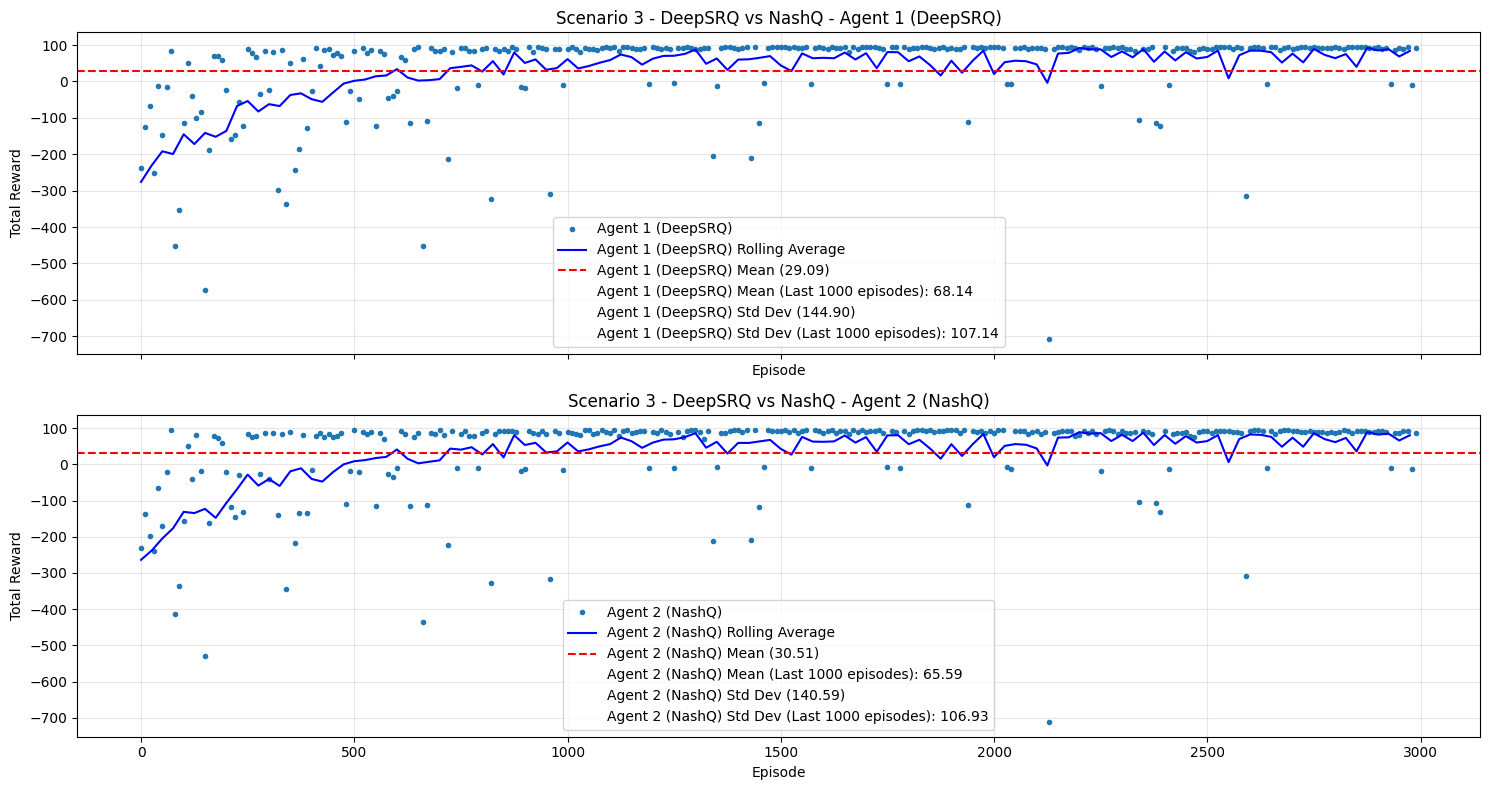

Saved stats to full_pair_comparison_runs/deep_srq_vs_nash_q/scenario3/deep_srq_exponential_eps0.25_vs_nashq_eps0.25_exponential_24125/training_stats.txt
Scenario 3 - DeepSRQ vs NashQ - deep_srq_exponential_eps0.25_vs_nashq_eps0.25_exponential_24125
Wall clock: 5510.945s (91.85 min)
Episode time:   count=3000, mean=1.836156s (1836155.55 us), min=0.372379s, max=12.861726s, std=1.557888s
SRE solve time: count=860813, mean=0.003048s (3047.76 us), min=0.001440s, max=0.115598s, std=0.002442s
Backend solve:  count=860813, mean=0.014932s (14931.55 us), min=0.007014s, max=1.716506s, std=0.006304s
  Agent 0 (deep_srq)
    SRE solve:  count=860813, mean=0.003048s (3047.76 us), min=0.001440s, max=0.115598s, std=0.002442s
    Backend:    count=860813, mean=0.014932s (14931.55 us), min=0.007014s, max=1.716506s, std=0.006304s
    Update:     count=57720, mean=0.046003s (46003.25 us), min=0.025504s, max=1.742567s, std=0.014460s
  Agent 1 (nashq)
    SRE solve:  count=0
    Backend:    count=0
    Upda

scenario3: deep_srq_vs_nashq: 100%|██████████| 3000/3000 [1:24:23<00:00,  1.69s/it]


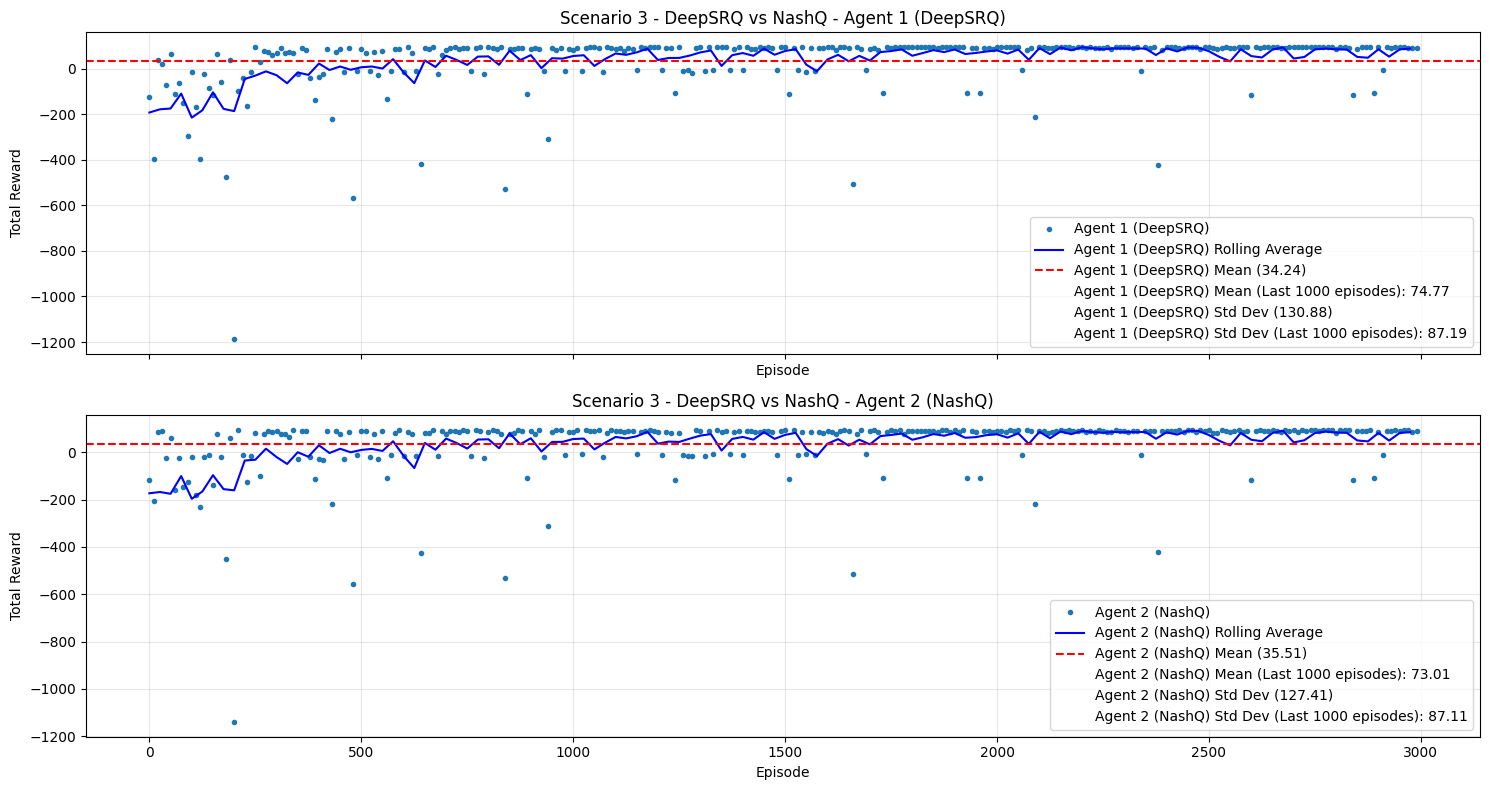

Saved stats to full_pair_comparison_runs/deep_srq_vs_nash_q/scenario3/deep_srq_exponential_eps0.5_vs_nashq_eps0.5_exponential_24126/training_stats.txt
Scenario 3 - DeepSRQ vs NashQ - deep_srq_exponential_eps0.5_vs_nashq_eps0.5_exponential_24126
Wall clock: 4974.062s (82.90 min)
Episode time:   count=3000, mean=1.657226s (1657225.85 us), min=0.202435s, max=12.138828s, std=1.421625s
SRE solve time: count=835188, mean=0.002726s (2726.09 us), min=0.001278s, max=0.253473s, std=0.002175s
Backend solve:  count=835188, mean=0.013557s (13557.38 us), min=0.006585s, max=0.839203s, std=0.004732s
  Agent 0 (deep_srq)
    SRE solve:  count=835188, mean=0.002726s (2726.09 us), min=0.001278s, max=0.253473s, std=0.002175s
    Backend:    count=835188, mean=0.013557s (13557.38 us), min=0.006585s, max=0.839203s, std=0.004732s
    Update:     count=56014, mean=0.041462s (41461.91 us), min=0.024455s, max=0.849817s, std=0.009414s
  Agent 1 (nashq)
    SRE solve:  count=0
    Backend:    count=0
    Update: 

scenario3: deep_srq_vs_nashq: 100%|██████████| 3000/3000 [1:24:50<00:00,  1.70s/it]


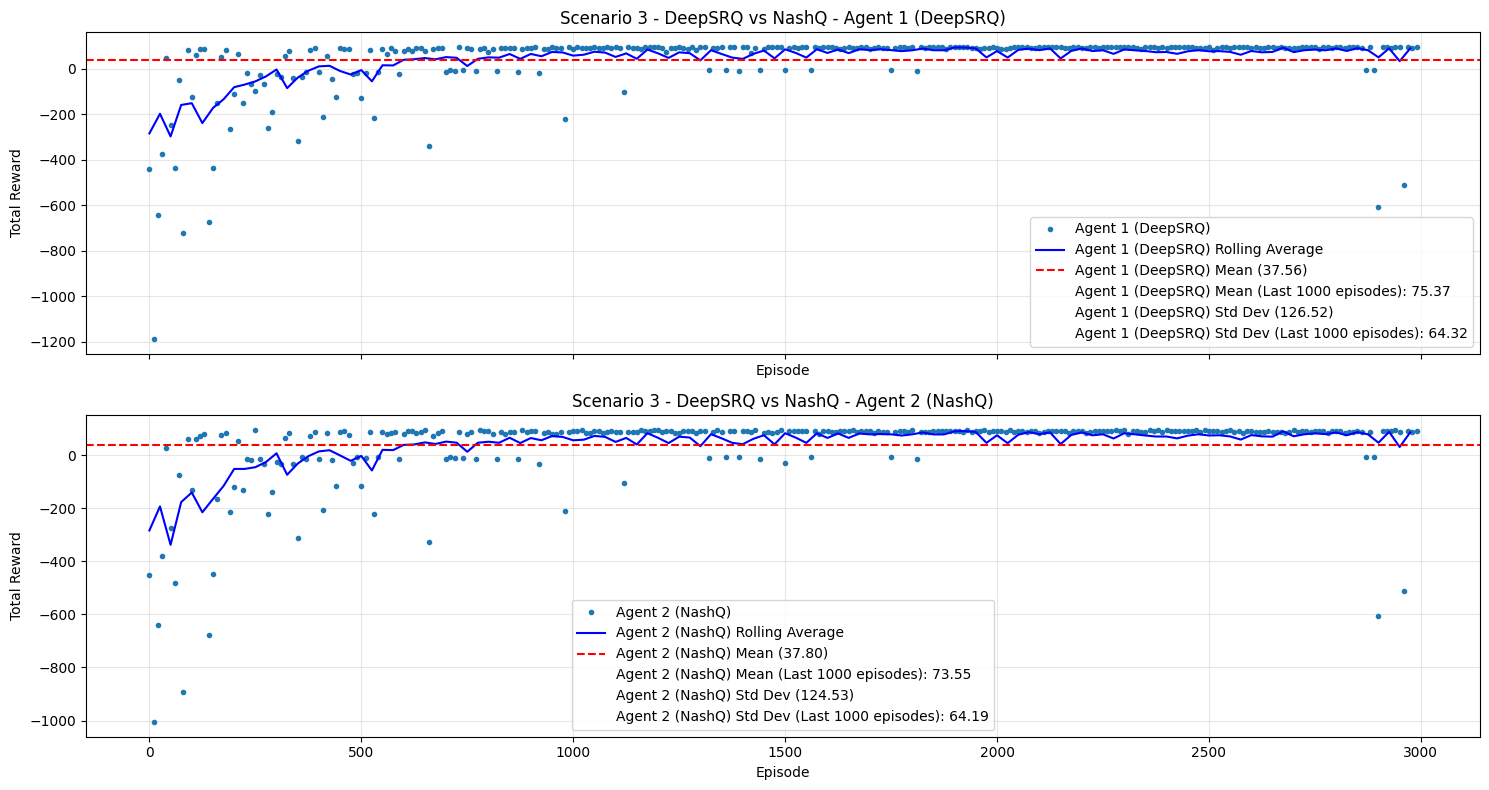

Saved stats to full_pair_comparison_runs/deep_srq_vs_nash_q/scenario3/deep_srq_exponential_eps1_vs_nashq_eps1_exponential_24127/training_stats.txt
Scenario 3 - DeepSRQ vs NashQ - deep_srq_exponential_eps1_vs_nashq_eps1_exponential_24127
Wall clock: 4999.517s (83.33 min)
Episode time:   count=3000, mean=1.665724s (1665724.44 us), min=0.409090s, max=11.542209s, std=1.562033s
SRE solve time: count=826535, mean=0.002846s (2846.04 us), min=0.001359s, max=1.038072s, std=0.002851s
Backend solve:  count=826535, mean=0.013929s (13929.11 us), min=0.006594s, max=1.653751s, std=0.006909s
  Agent 0 (deep_srq)
    SRE solve:  count=826535, mean=0.002846s (2846.04 us), min=0.001359s, max=1.038072s, std=0.002851s
    Backend:    count=826535, mean=0.013929s (13929.11 us), min=0.006594s, max=1.653751s, std=0.006909s
    Update:     count=55193, mean=0.043634s (43633.61 us), min=0.022440s, max=1.663009s, std=0.017871s
  Agent 1 (nashq)
    SRE solve:  count=0
    Backend:    count=0
    Update:     coun

scenario3: deep_srq_vs_nashq: 100%|██████████| 3000/3000 [1:23:59<00:00,  1.68s/it]


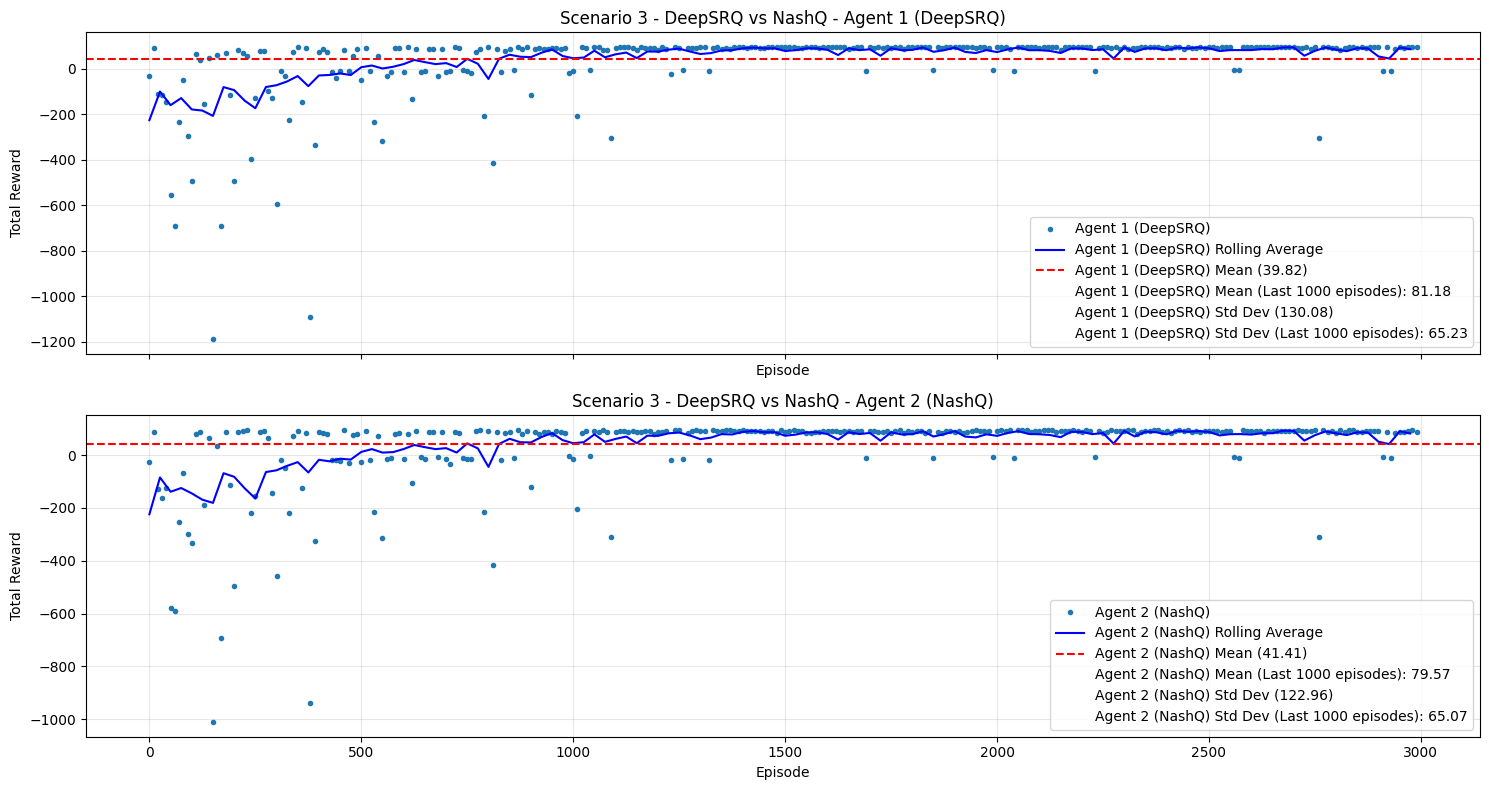

Saved stats to full_pair_comparison_runs/deep_srq_vs_nash_q/scenario3/deep_srq_constant_eps0.25_vs_nashq_eps0.25_constant_24225/training_stats.txt
Scenario 3 - DeepSRQ vs NashQ - deep_srq_constant_eps0.25_vs_nashq_eps0.25_constant_24225
Wall clock: 4931.574s (82.19 min)
Episode time:   count=3000, mean=1.643059s (1643059.46 us), min=0.291501s, max=11.355133s, std=1.546668s
SRE solve time: count=823088, mean=0.002727s (2727.17 us), min=0.001273s, max=1.108109s, std=0.002530s
Backend solve:  count=823088, mean=0.013629s (13628.94 us), min=0.006807s, max=1.222057s, std=0.005586s
  Agent 0 (deep_srq)
    SRE solve:  count=823088, mean=0.002727s (2727.17 us), min=0.001273s, max=1.108109s, std=0.002530s
    Backend:    count=823088, mean=0.013629s (13628.94 us), min=0.006807s, max=1.222057s, std=0.005586s
    Update:     count=55032, mean=0.041960s (41960.37 us), min=0.021314s, max=1.252182s, std=0.013344s
  Agent 1 (nashq)
    SRE solve:  count=0
    Backend:    count=0
    Update:     coun

scenario3: deep_srq_vs_nashq: 100%|██████████| 3000/3000 [1:21:23<00:00,  1.63s/it]


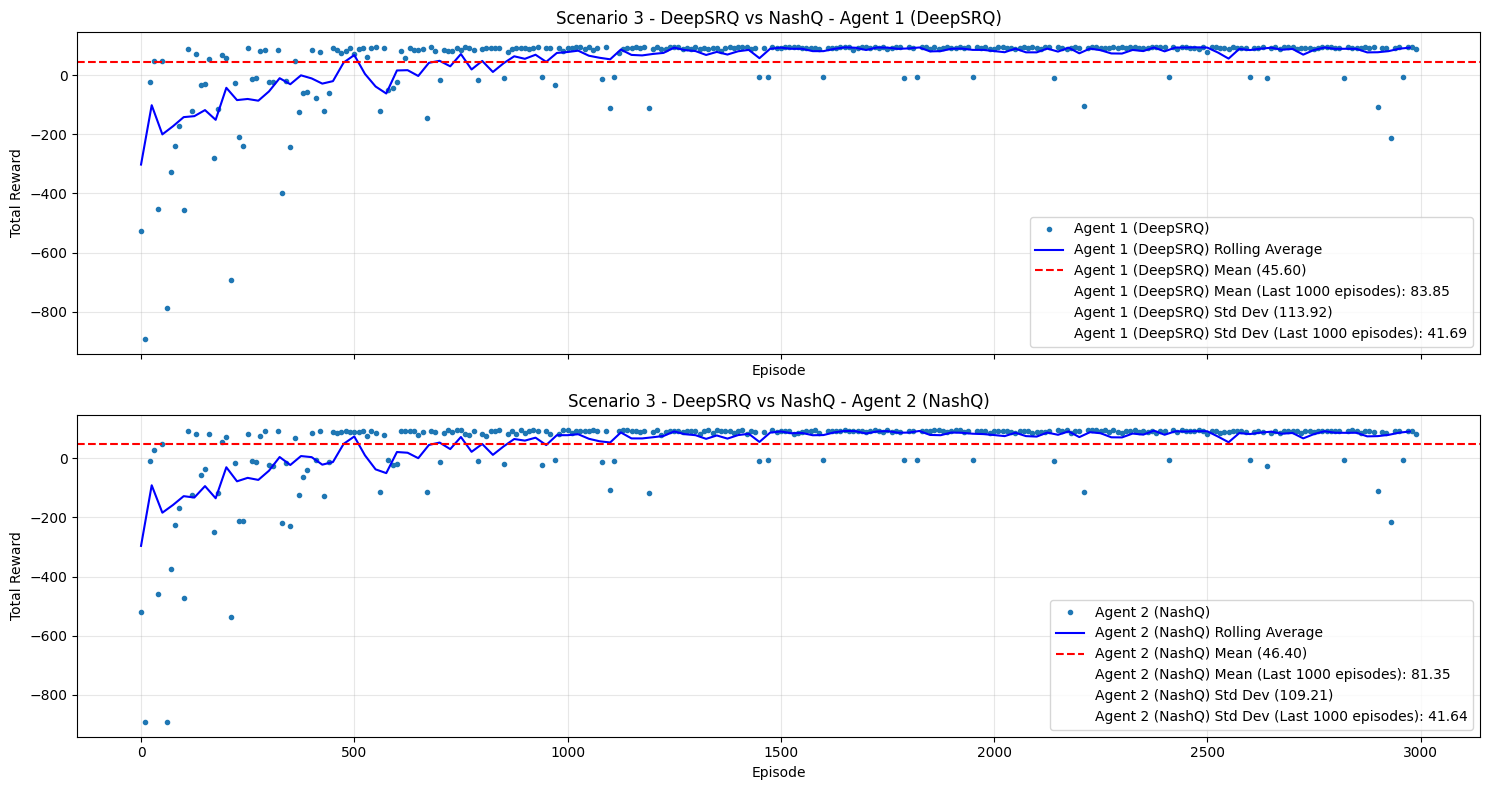

Saved stats to full_pair_comparison_runs/deep_srq_vs_nash_q/scenario3/deep_srq_constant_eps0.5_vs_nashq_eps0.5_constant_24226/training_stats.txt
Scenario 3 - DeepSRQ vs NashQ - deep_srq_constant_eps0.5_vs_nashq_eps0.5_constant_24226
Wall clock: 4743.811s (79.06 min)
Episode time:   count=3000, mean=1.580478s (1580477.60 us), min=0.332631s, max=12.072945s, std=1.414832s
SRE solve time: count=808004, mean=0.002689s (2689.28 us), min=0.001227s, max=0.072996s, std=0.002201s
Backend solve:  count=808004, mean=0.013314s (13313.74 us), min=0.006542s, max=1.152486s, std=0.005651s
  Agent 0 (deep_srq)
    SRE solve:  count=808004, mean=0.002689s (2689.28 us), min=0.001227s, max=0.072996s, std=0.002201s
    Backend:    count=808004, mean=0.013314s (13313.74 us), min=0.006542s, max=1.152486s, std=0.005651s
    Update:     count=53986, mean=0.041350s (41350.37 us), min=0.022687s, max=1.174013s, std=0.014405s
  Agent 1 (nashq)
    SRE solve:  count=0
    Backend:    count=0
    Update:     count=54

scenario3: deep_srq_vs_nashq: 100%|██████████| 3000/3000 [1:27:03<00:00,  1.74s/it]


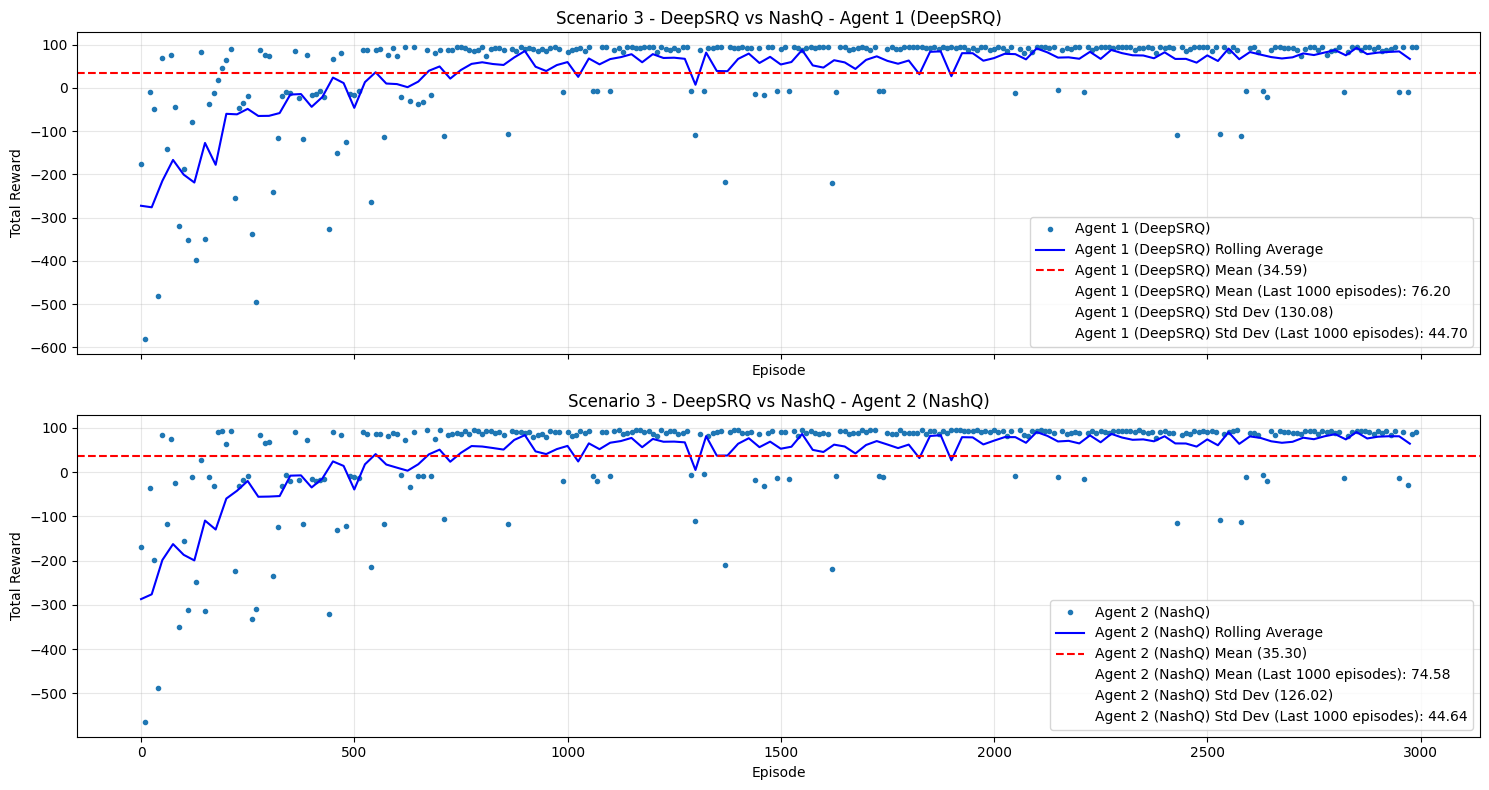

Saved stats to full_pair_comparison_runs/deep_srq_vs_nash_q/scenario3/deep_srq_constant_eps1_vs_nashq_eps1_constant_24227/training_stats.txt
Scenario 3 - DeepSRQ vs NashQ - deep_srq_constant_eps1_vs_nashq_eps1_constant_24227
Wall clock: 5066.806s (84.45 min)
Episode time:   count=3000, mean=1.688127s (1688127.41 us), min=0.445434s, max=11.287458s, std=1.453007s
SRE solve time: count=867451, mean=0.002604s (2604.33 us), min=0.001235s, max=0.715368s, std=0.002347s
Backend solve:  count=867451, mean=0.012974s (12973.79 us), min=0.006506s, max=1.074860s, std=0.005535s
  Agent 0 (deep_srq)
    SRE solve:  count=867451, mean=0.002604s (2604.33 us), min=0.001235s, max=0.715368s, std=0.002347s
    Backend:    count=867451, mean=0.012974s (12973.79 us), min=0.006506s, max=1.074860s, std=0.005535s
    Update:     count=57671, mean=0.040428s (40428.03 us), min=0.023787s, max=1.082984s, std=0.014282s
  Agent 1 (nashq)
    SRE solve:  count=0
    Backend:    count=0
    Update:     count=58670, mea

PosixPath('full_pair_comparison_runs/deep_srq_vs_nash_q_manifest.txt')

In [4]:
deep_srq_vs_nash_q_results = run_pair_epsilon_sweep(
    pairing=("deep_srq", "nashq"),
    case_slug="deep_srq_vs_nash_q",
    case_seed_offset=20_000,
    **common_sweep_kwargs,
)

save_training_stats(
    full_pair_output_root / "deep_srq_vs_nash_q_manifest.txt",
    deep_srq_vs_nash_q_results,
)
